# ChestMNIST, multi-label classification

## Overview

Multi-label classification of 28x28 chest X-rays (NIH ChestX-ray14, 14 findings). Train, val and test have 78,468, 11,219 and 22,433 images. Findings are rare: train prevalence runs from 0.0018 (hernia) to 0.177 (infiltration), and 48,484 of the 89,687 train and val images have no finding.

Arms:
- Baseline: ResNet-18, plain `BCEWithLogitsLoss`, Adam, no augmentation.
- pos_weight BCE: ResNet-20, `BCEWithLogitsLoss(pos_weight=...)`, Adam, augmentation.
- Focal Loss: ResNet-20, `sigmoid_focal_loss`, Adam, augmentation.
- Hand-picked: ResNet-20, LibAUC `MultiLabelAUCMLoss` with `PESG`, augmentation, fixed hyperparameters.

ResNet-18 keeps its ImageNet-style stem (7x7 stride-2 conv, max-pool), which shrinks a 28x28 input to 1x1 by the last stage. ResNet-20 uses a CIFAR-style stem (3x3 stride-1 conv, no max-pool).

pos_weight BCE has the highest test macro ROC-AUC (0.769), PR-AUC and thresholded metrics. Baseline (0.742) and Focal Loss (0.726) follow, and Hand-picked (0.633) is far behind. At 0.5 Baseline and Focal Loss predict almost no positives, so thresholds are also tuned per label on validation. pos_weight BCE changes the backbone and augmentation too, but Focal Loss shares those and scores 0.043 lower, so the loss probably matters most.

In [4]:
!pip install libauc medmnist

In [5]:
# pre-download from Zenodo (with retry/resume) into the medmnist cache
import os
os.makedirs('/root/.medmnist', exist_ok=True)
!wget -c --tries=5 --waitretry=15 -O /root/.medmnist/chestmnist.npz "https://zenodo.org/records/10519652/files/chestmnist.npz?download=1"
!md5sum /root/.medmnist/chestmnist.npz

--2026-09-26 16:07:56--  https://zenodo.org/records/10519652/files/chestmnist.npz?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 188.184.98.114, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 416 REQUESTED_RANGE_NOT_SATISFIABLE

    The file is already fully retrieved; nothing to do.

02c8a6516a18b556561a56cbdd36c4a8  /root/.medmnist/chestmnist.npz


## Setup and data

Imports, the ChestMNIST dataset (official split) and per-label class statistics.

In [6]:
from sklearn import metrics
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data as data
import torchvision.transforms as transforms
from dataCentric_functions import *

import medmnist
from medmnist import INFO

In [7]:
from libauc.optimizers import PESG
from libauc.models import resnet20 as ResNet20
from libauc.models import resnet18 as ResNet18


In [8]:
import matplotlib.pyplot as plt

In [9]:
import os

# output directory for saved checkpoints
if not os.path.exists('chest'):
    os.makedirs('chest')

In [10]:
data_flag = 'chestmnist'
download = True

info = INFO[data_flag]

DataClass = getattr(medmnist, info['python_class'])

In [11]:
# ToTensor: uint8 [0, 255] -> float [0, 1], shape (1, 28, 28)
data_transform1 = transforms.Compose([
    transforms.ToTensor()
])


/usr/local/lib/python3.13/dist-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [12]:
train_dataset1 = DataClass(split='train', transform=data_transform1, download=download)
val_dataset1 = DataClass(split='val', transform=data_transform1, download=download)
test_dataset = DataClass(split='test', transform=data_transform1, download=download)

train_dataset1

Dataset ChestMNIST of size 28 (chestmnist)
    Number of datapoints: 78468
    Root location: /root/.medmnist
    Split: train
    Task: multi-label, binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'atelectasis', '1': 'cardiomegaly', '2': 'effusion', '3': 'infiltration', '4': 'mass', '5': 'nodule', '6': 'pneumonia', '7': 'pneumothorax', '8': 'consolidation', '9': 'edema', '10': 'emphysema', '11': 'fibrosis', '12': 'pleural', '13': 'hernia'}
    Number of samples: {'train': 78468, 'val': 11219, 'test': 22433}
    Description: The ChestMNIST is based on the NIH-ChestXray14 dataset, a dataset comprising 112,120 frontal-view X-Ray images of 30,805 unique patients with the text-mined 14 disease labels, which could be formulized as a multi-label binary-class classification task. We use the official data split, and resize the source images of 1×1024×1024 into 1×28×28.
    License: CC BY 4.0

In [13]:
# per-label positive counts and rates per split (labels is an (N, 14) multi-hot matrix)
disease_names = list(info['label'].values())

def per_class_stats(labels, split_name):
    n = labels.shape[0]
    pos_counts = labels.sum(axis=0)
    pos_rate = pos_counts / n
    print(f"--- {split_name} (n={n}) ---")
    for name, cnt, rate in zip(disease_names, pos_counts, pos_rate):
        print(f"  {name:15s} pos={int(cnt):6d}  rate={rate:.4f}")
    return pos_counts, pos_rate

train_pos_counts, train_pos_rate = per_class_stats(train_dataset1.labels, "train")
val_pos_counts, val_pos_rate = per_class_stats(val_dataset1.labels, "val")
test_pos_counts, test_pos_rate = per_class_stats(test_dataset.labels, "test")

--- train (n=78468) ---
  atelectasis     pos=  7996  rate=0.1019
  cardiomegaly    pos=  1950  rate=0.0249
  effusion        pos=  9261  rate=0.1180
  infiltration    pos= 13914  rate=0.1773
  mass            pos=  3988  rate=0.0508
  nodule          pos=  4375  rate=0.0558
  pneumonia       pos=   978  rate=0.0125
  pneumothorax    pos=  3705  rate=0.0472
  consolidation   pos=  3263  rate=0.0416
  edema           pos=  1690  rate=0.0215
  emphysema       pos=  1799  rate=0.0229
  fibrosis        pos=  1158  rate=0.0148
  pleural         pos=  2279  rate=0.0290
  hernia          pos=   144  rate=0.0018
--- val (n=11219) ---
  atelectasis     pos=  1119  rate=0.0997
  cardiomegaly    pos=   240  rate=0.0214
  effusion        pos=  1292  rate=0.1152
  infiltration    pos=  2018  rate=0.1799
  mass            pos=   625  rate=0.0557
  nodule          pos=   613  rate=0.0546
  pneumonia       pos=   133  rate=0.0119
  pneumothorax    pos=   504  rate=0.0449
  consolidation   pos=   447  

In [14]:
# per-label positive rate in train+val vs. test, flag differences above 0.01
trainval_n = train_dataset1.labels.shape[0] + val_dataset1.labels.shape[0]
trainval_pos_rate = (train_pos_counts + val_pos_counts) / trainval_n

print(f"{'disease':15s} {'train+val':>10s} {'test':>10s} {'diff':>8s}")
for name, tv_rate, t_rate in zip(disease_names, trainval_pos_rate, test_pos_rate):
    diff = t_rate - tv_rate
    flag = "  <-- check" if abs(diff) > 0.01 else ""
    print(f"{name:15s} {tv_rate:10.4f} {t_rate:10.4f} {diff:+8.4f}{flag}")

disease          train+val       test     diff
atelectasis         0.1016     0.1079  +0.0062
cardiomegaly        0.0244     0.0259  +0.0015
effusion            0.1177     0.1228  +0.0051
infiltration        0.1776     0.1755  -0.0021
mass                0.0514     0.0505  -0.0009
nodule              0.0556     0.0595  +0.0039
pneumonia           0.0124     0.0108  -0.0016
pneumothorax        0.0469     0.0485  +0.0016
consolidation       0.0414     0.0427  +0.0013
edema               0.0211     0.0184  -0.0027
emphysema           0.0224     0.0227  +0.0003
fibrosis            0.0148     0.0161  +0.0014
pleural             0.0296     0.0327  +0.0032
hernia              0.0021     0.0019  -0.0002


In [15]:
t_v_labels = np.row_stack([train_dataset1.labels, val_dataset1.labels])
print(t_v_labels.shape)

# per-label positive counts over train+val
class_counts = t_v_labels.sum(axis=0)
print(dict(zip(disease_names, class_counts.astype(int))))
class_counts

(89687, 14)
{'atelectasis': np.int64(9115), 'cardiomegaly': np.int64(2190), 'effusion': np.int64(10553), 'infiltration': np.int64(15932), 'mass': np.int64(4613), 'nodule': np.int64(4988), 'pneumonia': np.int64(1111), 'pneumothorax': np.int64(4209), 'consolidation': np.int64(3710), 'edema': np.int64(1890), 'emphysema': np.int64(2007), 'fibrosis': np.int64(1324), 'pleural': np.int64(2651), 'hernia': np.int64(185)}


/tmp/ipykernel_3587/1244426358.py:1: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  t_v_labels = np.row_stack([train_dataset1.labels, val_dataset1.labels])


array([ 9115,  2190, 10553, 15932,  4613,  4988,  1111,  4209,  3710,
        1890,  2007,  1324,  2651,   185], dtype=uint64)

In [16]:
# total over labels (an image with 2 findings counts twice)
total_positive_label_instances = class_counts.sum()

In [17]:
# train+val images with no positive label
zero_class = t_v_labels[np.all(t_v_labels == 0, axis=1)]

In [18]:
total_images = len(train_dataset1) + len(val_dataset1)
num_images_with_any_class = total_images - len(zero_class)

print(f"total positive label instances (multi-label, double-counts multi-disease images): {total_positive_label_instances}")
print(f"images with >=1 positive label: {num_images_with_any_class}")
print(f"images with 0 positive labels: {len(zero_class)}")
print(f"check: {num_images_with_any_class} + {len(zero_class)} = {num_images_with_any_class + len(zero_class)} "
      f"(should equal total images = {total_images})")

total positive label instances (multi-label, double-counts multi-disease images): 64478
images with >=1 positive label: 41203
images with 0 positive labels: 48484
check: 41203 + 48484 = 89687 (should equal total images = 89687)


## Augmentation

Training images get random augmentation (`OnTheFlyAugment`) for the pos_weight, Focal and Hand-picked arms: horizontal flip (p 0.5), rotation up to 10 degrees (p 0.5), brightness and contrast jitter of 0.3 (p 0.5) and Gaussian noise with std 0.1 (p 0.3). Baseline uses no augmentation. Validation and test images are never augmented.

In [19]:
# on-the-fly augmentation of training images only
# no vertical flip (upside-down X-rays aren't valid), rotation within +/-10 degrees
stochastic_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.RandomRotation(degrees=10)], p=0.5),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=0.3)], p=0.5),
    transforms.RandomApply([AddGaussianNoise(0., 0.1)], p=0.3),
])

In [20]:
# train_d: full training set with augmentation. val_d: untouched validation set
train_d = OnTheFlyAugment(train_dataset1, stochastic_augment)

val_imgs = torch.from_numpy(val_dataset1.imgs.astype(np.float32) / 255.0).unsqueeze(1)
val_labels = torch.from_numpy(val_dataset1.labels)
val_d = torch.utils.data.TensorDataset(val_imgs, val_labels)

len(val_d), len(train_d)

(11219, 78468)

### Per-label train counts

Used for the `pos_weight` values.

In [21]:
# per-label positive counts in train (input to pos_weight)
train_class_counts = train_dataset1.labels.sum(axis=0)
print(dict(zip(disease_names, train_class_counts.astype(int))))

{'atelectasis': np.int64(7996), 'cardiomegaly': np.int64(1950), 'effusion': np.int64(9261), 'infiltration': np.int64(13914), 'mass': np.int64(3988), 'nodule': np.int64(4375), 'pneumonia': np.int64(978), 'pneumothorax': np.int64(3705), 'consolidation': np.int64(3263), 'edema': np.int64(1690), 'emphysema': np.int64(1799), 'fibrosis': np.int64(1158), 'pleural': np.int64(2279), 'hernia': np.int64(144)}


## Training settings

All arms use batch size 512, up to 50 epochs, the natural class distribution (shuffled, no resampling), patience 7 and `MIN_DELTA` 0.001. Validation macro ROC-AUC is computed once per epoch, after its first batch, and the best-validation checkpoint is restored at the end.

Patience counts epochs where val AUC fell or rose by at most `MIN_DELTA` versus the previous epoch (not versus the best), so a noisy curve can run all 50 epochs.

In [22]:
# an epoch counts against patience when val AUC falls, or rises by at most MIN_DELTA, versus the previous epoch
MIN_DELTA = 1e-3

## Baseline

LibAUC `resnet18` (one input channel, 14 logits, ImageNet-style stem) with `BCEWithLogitsLoss` and Adam (lr 1e-3, weight decay 1e-4). It trains on `train_dataset1` and validates on `val_dataset1`, with no augmentation.

In [23]:
# per-arm report: confusion matrices, classification report, macro balanced acc / MCC / PR-AUC
# thresholds=None means 0.5 for every label, else one per label. y_score must be sigmoid probabilities
from sklearn.metrics import (multilabel_confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              balanced_accuracy_score, average_precision_score, matthews_corrcoef)

def multilabel_metrics_report(y_true, y_score, label_names, title, thresholds=None):
    y_true = y_true.astype(int)
    if thresholds is None:
        y_pred = (y_score >= 0.5).astype(int)
    else:
        y_pred = (y_score >= np.asarray(thresholds)[None, :]).astype(int)
        title = f'{title}, tuned thresholds'
    n_labels = y_true.shape[1]

    # one 2x2 confusion matrix per label, in a grid
    ncols = 4
    nrows = int(np.ceil(n_labels / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
    axes = axes.flatten()
    mcm = multilabel_confusion_matrix(y_true, y_pred)
    for i in range(n_labels):
        ConfusionMatrixDisplay(confusion_matrix=mcm[i]).plot(ax=axes[i], cmap='Blues', colorbar=False)
        axes[i].set_title(label_names[i], fontsize=10)
    for i in range(n_labels, len(axes)):
        axes[i].axis('off')
    fig.suptitle(f'Per-label confusion matrices -- {title}', fontsize=14)
    plt.tight_layout()
    plt.show()

    print(classification_report(y_true, y_pred, target_names=label_names, digits=4, zero_division=0))

    # balanced accuracy and MCC: per label at the chosen threshold, then macro-averaged like the macro AUC
    bal_acc_per_label = [balanced_accuracy_score(y_true[:, i], y_pred[:, i]) for i in range(n_labels)]
    mcc_per_label = [matthews_corrcoef(y_true[:, i], y_pred[:, i]) for i in range(n_labels)]
    print("Macro balanced accuracy: %.4f" % np.mean(bal_acc_per_label))
    print("Macro Matthews correlation coefficient: %.4f" % np.mean(mcc_per_label))

    # macro PR-AUC: average precision per label. threshold-free, but depends on prevalence, so rare labels score low
    pr_auc_macro = average_precision_score(y_true, y_score, average='macro')
    print("Macro PR-AUC (average precision): %.4f" % pr_auc_macro)

In [24]:
BASELINE_BATCH_SIZE = 512
baseline_lr = 1e-3
baseline_epochs = 50
baseline_patience = 7

# plain shuffled loaders, natural class distribution
baseline_trainloader = data.DataLoader(dataset=train_dataset1, batch_size=BASELINE_BATCH_SIZE, shuffle=True)
baseline_valloader = data.DataLoader(dataset=val_dataset1, batch_size=BASELINE_BATCH_SIZE, shuffle=False, num_workers=2)
baseline_trainloader_eval = data.DataLoader(dataset=train_dataset1, batch_size=BASELINE_BATCH_SIZE, shuffle=False, num_workers=2)

# ResNet-18: ImageNet-style stem, see Overview
baseline_model = ResNet18(pretrained=False, last_activation=None, num_classes=14)
baseline_model.conv1 = torch.nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=baseline_lr, weight_decay=0.0001)

# returns None, best-val-AUC weights are restored in place
train_with_logits_loss(baseline_model, nn.BCEWithLogitsLoss(), baseline_optimizer, baseline_epochs,
                       baseline_trainloader, baseline_trainloader_eval, baseline_valloader,
                       patience=baseline_patience, min_delta=MIN_DELTA)

Start Training
------------------------------
device: cuda
Epoch=0, BatchID=0, Val_AUC=0.5125
0
Epoch=1, BatchID=0, Val_AUC=0.7003
0
Epoch=2, BatchID=0, Val_AUC=0.7157
0
Epoch=3, BatchID=0, Val_AUC=0.7067
1
Epoch=4, BatchID=0, Val_AUC=0.7217
0
Epoch=5, BatchID=0, Val_AUC=0.7260
0
Epoch=6, BatchID=0, Val_AUC=0.7212
1
Epoch=7, BatchID=0, Val_AUC=0.7320
0
Epoch=8, BatchID=0, Val_AUC=0.7238
1
Epoch=9, BatchID=0, Val_AUC=0.7379
0
Epoch=10, BatchID=0, Val_AUC=0.7201
1
Epoch=11, BatchID=0, Val_AUC=0.7396
0
Epoch=12, BatchID=0, Val_AUC=0.7468
0
Epoch=13, BatchID=0, Val_AUC=0.7466
1
Epoch=14, BatchID=0, Val_AUC=0.7171
2
Epoch=15, BatchID=0, Val_AUC=0.7454
0
Epoch=16, BatchID=0, Val_AUC=0.7194
1
Epoch=17, BatchID=0, Val_AUC=0.7491
0
Epoch=18, BatchID=0, Val_AUC=0.7485
1
Epoch=19, BatchID=0, Val_AUC=0.7485
2
Epoch=20, BatchID=0, Val_AUC=0.7501
0
Epoch=21, BatchID=0, Val_AUC=0.7473
1
Epoch=22, BatchID=0, Val_AUC=0.7266
2
Epoch=23, BatchID=0, Val_AUC=0.7382
0
Epoch=24, BatchID=0, Val_AUC=0.7338
1
E

In [25]:
# baseline: test ROC-AUC (per label and macro)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
baseline_test_loader = data.DataLoader(dataset=test_dataset, batch_size=BASELINE_BATCH_SIZE)

score_list, label_list = [], []
# eval mode: BatchNorm uses running statistics. The train function leaves the model in
# train mode after restoring the best checkpoint, so eval() has to be called here.
baseline_model.eval()
with torch.no_grad():
    for _, d in enumerate(baseline_test_loader, 0):
        tmp_data, tmp_label = d
        tmp_data = tmp_data.to(device)
        tmp_score = torch.sigmoid(baseline_model(tmp_data)).detach().clone().cpu()
        score_list.append(tmp_score)
        label_list.append(tmp_label.cpu())

baseline_test_label = torch.cat(label_list)
baseline_test_score = torch.cat(score_list)

baseline_test_auc_per_label = metrics.roc_auc_score(baseline_test_label, baseline_test_score, average=None)
baseline_test_auc_mean = metrics.roc_auc_score(baseline_test_label, baseline_test_score, average='macro')
print("Per-label test AUC (baseline):", baseline_test_auc_per_label)
print("Mean test AUC (baseline): %.4f" % baseline_test_auc_mean)

Per-label test AUC (baseline): [0.74132575 0.84776936 0.81415398 0.66672669 0.70956377 0.61749712
 0.68544624 0.76288892 0.76515239 0.86097533 0.77033082 0.71242338
 0.696548   0.74219021]
Mean test AUC (baseline): 0.7424


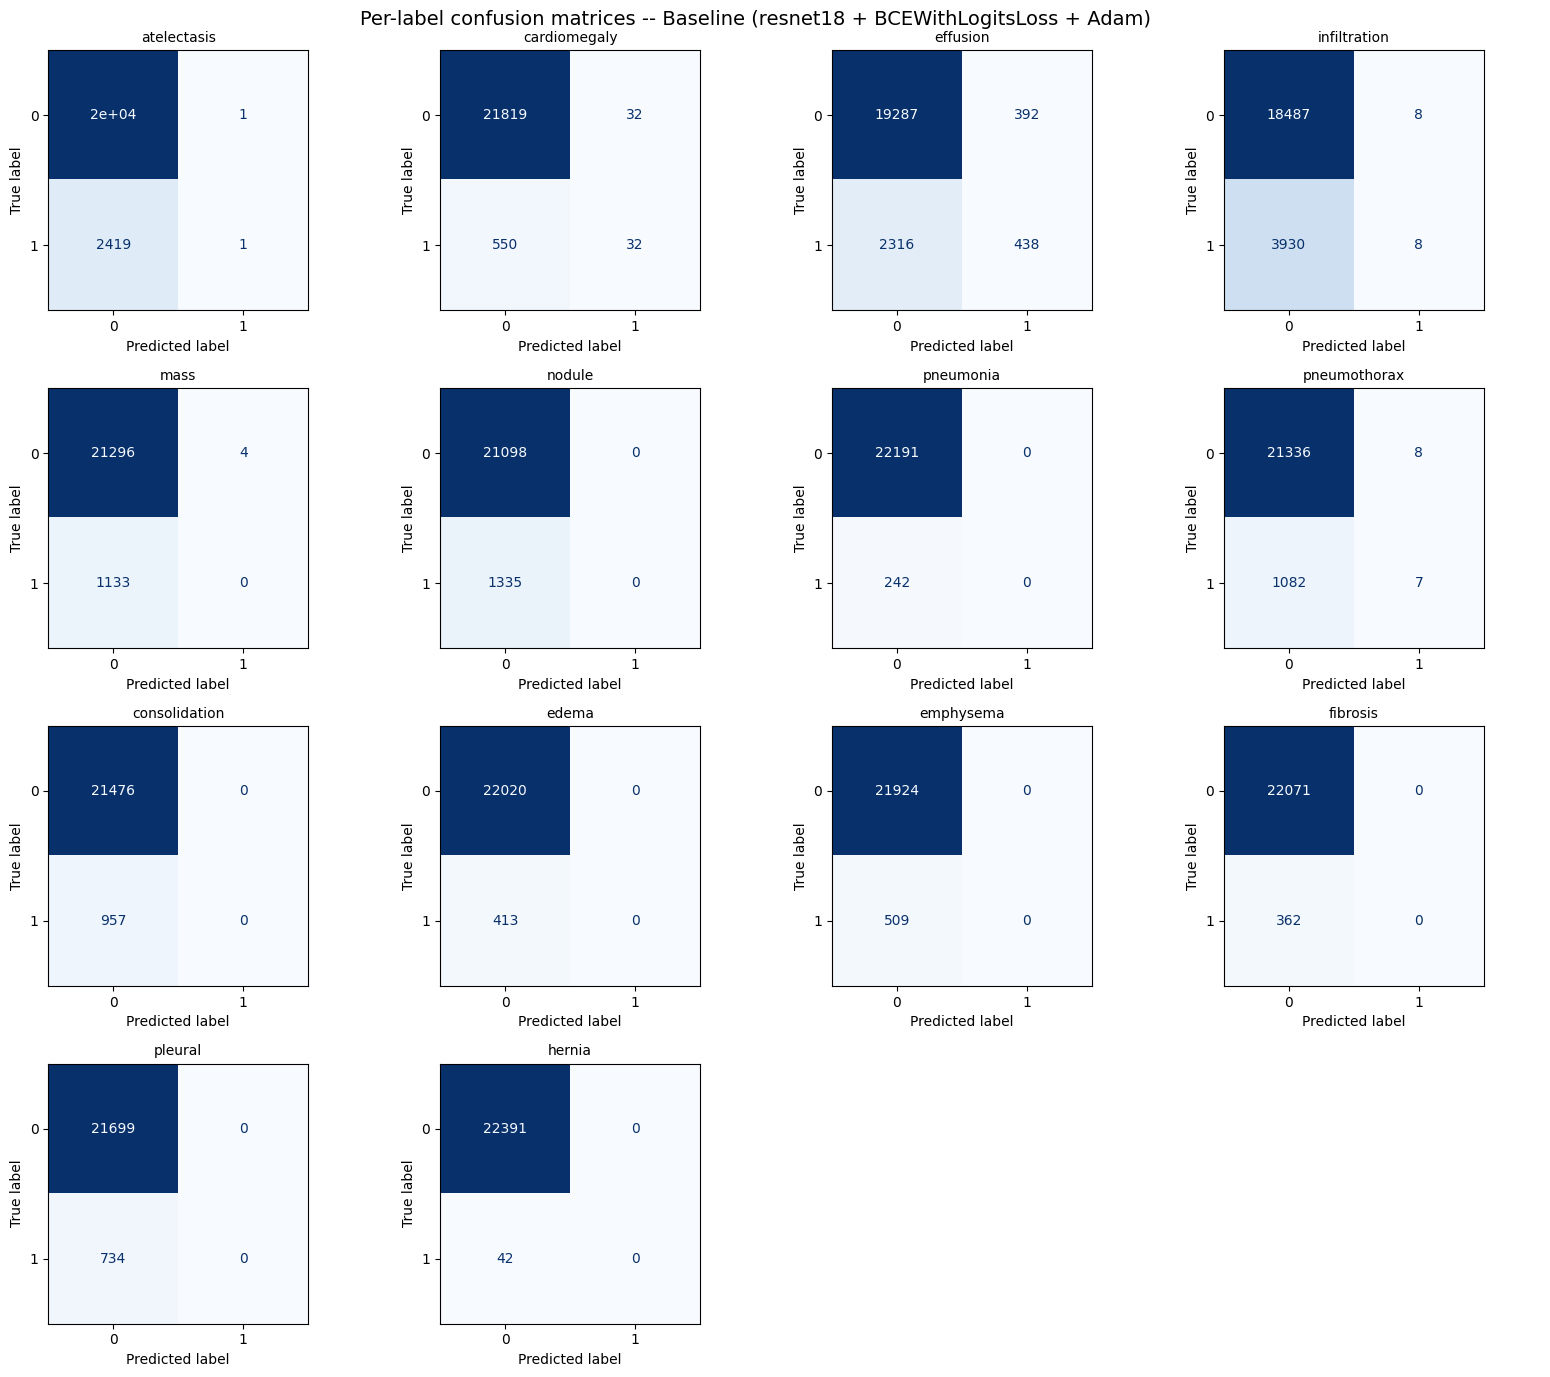

               precision    recall  f1-score   support

  atelectasis     0.5000    0.0004    0.0008      2420
 cardiomegaly     0.5000    0.0550    0.0991       582
     effusion     0.5277    0.1590    0.2444      2754
 infiltration     0.5000    0.0020    0.0040      3938
         mass     0.0000    0.0000    0.0000      1133
       nodule     0.0000    0.0000    0.0000      1335
    pneumonia     0.0000    0.0000    0.0000       242
 pneumothorax     0.4667    0.0064    0.0127      1089
consolidation     0.0000    0.0000    0.0000       957
        edema     0.0000    0.0000    0.0000       413
    emphysema     0.0000    0.0000    0.0000       509
     fibrosis     0.0000    0.0000    0.0000       362
      pleural     0.0000    0.0000    0.0000       734
       hernia     0.0000    0.0000    0.0000        42

    micro avg     0.5220    0.0294    0.0557     16510
    macro avg     0.1782    0.0159    0.0258     16510
 weighted avg     0.3290    0.0294    0.0462     16510
  sample

In [26]:
multilabel_metrics_report(baseline_test_label.numpy(), baseline_test_score.numpy(), disease_names,
                           "Baseline (resnet18 + BCEWithLogitsLoss + Adam)")

In [27]:
# save baseline weights
torch.save(baseline_model.state_dict(), "chest/chest_baseline.pth")

## pos_weight BCE

`BCEWithLogitsLoss(pos_weight=...)` and Adam (lr 1e-3, weight decay 1e-4) on ResNet-20 with `train_d` (augmented) and `val_d`. Each label's positive term is weighted by `((n_train - count) / count) ** 0.5`, the square root of its negative to positive ratio. The weights run from 2.15 (infiltration) to 23.32 (hernia).

### pos_weight BCE: training

In [28]:
POS_WEIGHT_BATCH_SIZE = 512
pos_weight_lr = 1e-3
pos_weight_epochs = 50
pos_weight_patience = 7
POS_WEIGHT_POWER = 0.5  # sqrt tempering of neg/pos. 1.0 is the full ratio, 0.0 is no weighting

pos_weight_trainloader = data.DataLoader(dataset=train_d, batch_size=POS_WEIGHT_BATCH_SIZE, shuffle=True)
pos_weight_valloader = data.DataLoader(dataset=val_d, batch_size=POS_WEIGHT_BATCH_SIZE, shuffle=False, num_workers=2)
pos_weight_trainloader_eval = data.DataLoader(dataset=train_d, batch_size=POS_WEIGHT_BATCH_SIZE, shuffle=False, num_workers=2)

# ResNet-20: CIFAR-style stem, see Overview
pos_weight_model = ResNet20(pretrained=False, last_activation=None, num_classes=14)
pos_weight_model.conv1 = torch.nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False)

pos_weight_optimizer = torch.optim.Adam(pos_weight_model.parameters(), lr=pos_weight_lr, weight_decay=0.0001)

# per-label pos_weight = (negatives / positives) ** POS_WEIGHT_POWER, float32 on the model's device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_train = len(train_d)
neg_pos_ratio = (n_train - train_class_counts.astype(np.float64)) / train_class_counts.astype(np.float64)
pos_weight = torch.tensor(neg_pos_ratio ** POS_WEIGHT_POWER, dtype=torch.float32, device=device)
for label_name, w in zip(disease_names, pos_weight.cpu().numpy()):
    print(f"  {label_name:15s} pos_weight={w:.2f}")

# returns None, best-val-AUC weights are restored in place
train_with_logits_loss(pos_weight_model, nn.BCEWithLogitsLoss(pos_weight=pos_weight), pos_weight_optimizer,
                       pos_weight_epochs, pos_weight_trainloader, pos_weight_trainloader_eval, pos_weight_valloader,
                       patience=pos_weight_patience, min_delta=MIN_DELTA)

  atelectasis     pos_weight=2.97
  cardiomegaly    pos_weight=6.26
  effusion        pos_weight=2.73
  infiltration    pos_weight=2.15
  mass            pos_weight=4.32
  nodule          pos_weight=4.12
  pneumonia       pos_weight=8.90
  pneumothorax    pos_weight=4.49
  consolidation   pos_weight=4.80
  edema           pos_weight=6.74
  emphysema       pos_weight=6.53
  fibrosis        pos_weight=8.17
  pleural         pos_weight=5.78
  hernia          pos_weight=23.32
Start Training
------------------------------
device: cuda
Epoch=0, BatchID=0, Val_AUC=0.5202
0
Epoch=1, BatchID=0, Val_AUC=0.6917
0
Epoch=2, BatchID=0, Val_AUC=0.7057
0
Epoch=3, BatchID=0, Val_AUC=0.7078
0
Epoch=4, BatchID=0, Val_AUC=0.7387
0
Epoch=5, BatchID=0, Val_AUC=0.7372
1
Epoch=6, BatchID=0, Val_AUC=0.7355
2
Epoch=7, BatchID=0, Val_AUC=0.7379
0
Epoch=8, BatchID=0, Val_AUC=0.7484
0
Epoch=9, BatchID=0, Val_AUC=0.7482
1
Epoch=10, BatchID=0, Val_AUC=0.7474
2
Epoch=11, BatchID=0, Val_AUC=0.7555
0
Epoch=12, BatchID=

In [29]:
# pos_weight BCE: test ROC-AUC
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pos_weight_test_loader = data.DataLoader(dataset=test_dataset, batch_size=POS_WEIGHT_BATCH_SIZE)

score_list, label_list = [], []
# eval mode: BatchNorm uses running statistics
pos_weight_model.eval()
with torch.no_grad():
    for _, d in enumerate(pos_weight_test_loader, 0):
        tmp_data, tmp_label = d
        tmp_data = tmp_data.to(device)
        tmp_score = torch.sigmoid(pos_weight_model(tmp_data)).detach().clone().cpu()
        score_list.append(tmp_score)
        label_list.append(tmp_label.cpu())

pos_weight_test_label = torch.cat(label_list)
pos_weight_test_score = torch.cat(score_list)

pos_weight_test_auc_per_label = metrics.roc_auc_score(pos_weight_test_label, pos_weight_test_score, average=None)
pos_weight_test_auc_mean = metrics.roc_auc_score(pos_weight_test_label, pos_weight_test_score, average='macro')
print("Per-label test AUC (pos_weight BCE):", pos_weight_test_auc_per_label)
print("Mean test AUC (pos_weight BCE): %.4f" % pos_weight_test_auc_mean)

Per-label test AUC (pos_weight BCE): [0.75583445 0.88107718 0.82551391 0.66975773 0.73700788 0.63336225
 0.70390768 0.80752582 0.77933459 0.87659914 0.8027389  0.75035089
 0.71670043 0.83248052]
Mean test AUC (pos_weight BCE): 0.7694


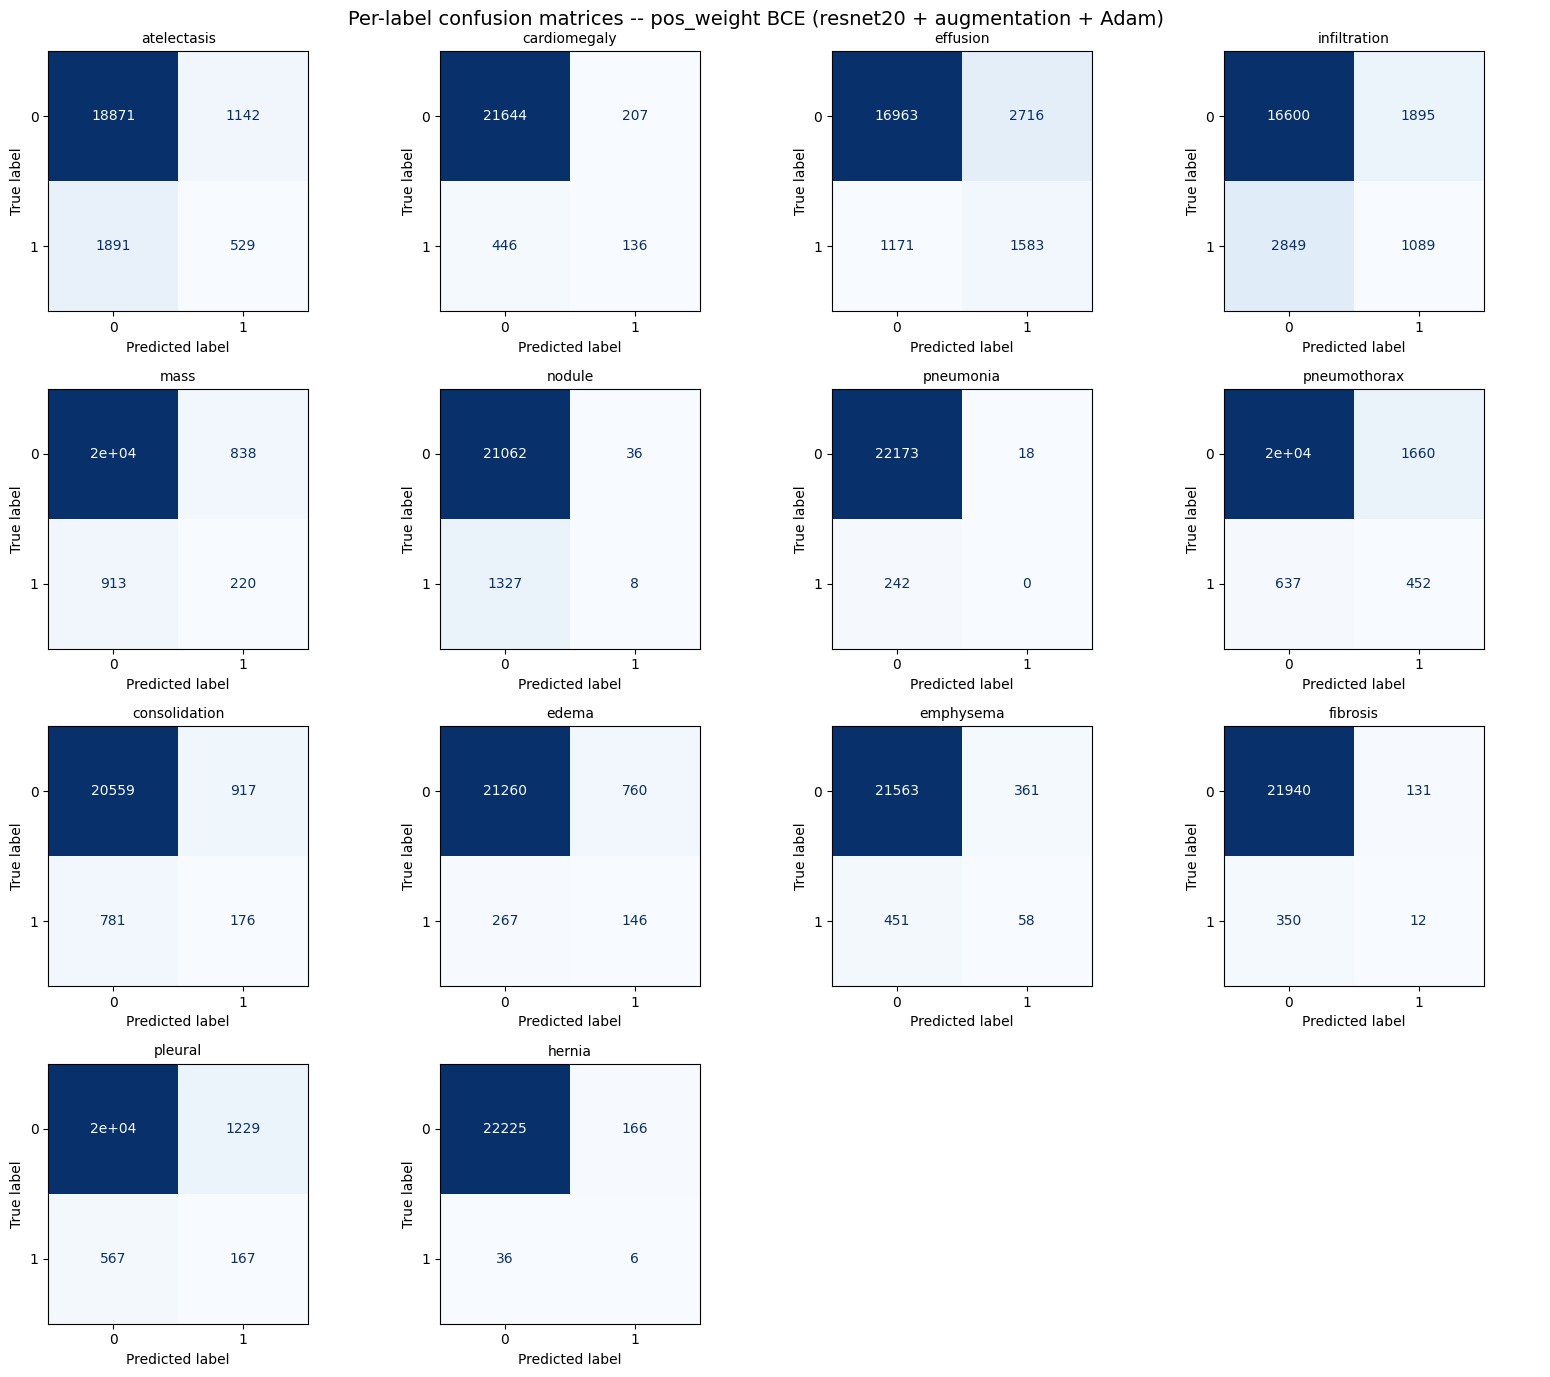

               precision    recall  f1-score   support

  atelectasis     0.3166    0.2186    0.2586      2420
 cardiomegaly     0.3965    0.2337    0.2941       582
     effusion     0.3682    0.5748    0.4489      2754
 infiltration     0.3649    0.2765    0.3146      3938
         mass     0.2079    0.1942    0.2008      1133
       nodule     0.1818    0.0060    0.0116      1335
    pneumonia     0.0000    0.0000    0.0000       242
 pneumothorax     0.2140    0.4151    0.2824      1089
consolidation     0.1610    0.1839    0.1717       957
        edema     0.1611    0.3535    0.2214       413
    emphysema     0.1384    0.1139    0.1250       509
     fibrosis     0.0839    0.0331    0.0475       362
      pleural     0.1196    0.2275    0.1568       734
       hernia     0.0349    0.1429    0.0561        42

    micro avg     0.2751    0.2775    0.2763     16510
    macro avg     0.1964    0.2124    0.1850     16510
 weighted avg     0.2768    0.2775    0.2590     16510
  sample

In [30]:
multilabel_metrics_report(pos_weight_test_label.numpy(), pos_weight_test_score.numpy(), disease_names,
                           "pos_weight BCE (resnet20 + augmentation + Adam)")

In [31]:
# save pos_weight BCE weights
torch.save(pos_weight_model.state_dict(), "chest/chest_pos_weight.pth")

## Hand-picked

LibAUC `MultiLabelAUCMLoss` with `PESG` on ResNet-20, `train_d` and `val_d`. The single-task `AUCMLoss` doesn't handle 14 labels, so the multi-label loss keeps `a`, `b` and `alpha` per label and averages the per-label losses. `multilabel_train` applies the sigmoid before the loss.

- lr 0.1, margin 1.0, epoch_decay 0.003, weight decay 1e-4, lr divided by 10 at epochs 25 and 40.
- These values are fixed, not tuned. Early stopping ended the run at epoch 35, before the second lr drop.

### Hand-picked: training

In [32]:
from libauc.losses import MultiLabelAUCMLoss

AUCM_BATCH_SIZE = 512
aucm_lr = 0.1
aucm_margin = 1.0
aucm_epoch_decay = 0.003  # refers to gamma in the paper
aucm_weight_decay = 0.0001
aucm_epochs = 50
aucm_decay_epochs = [25, 40]  # 50% / 80% of aucm_epochs, each decay divides lr by 10
aucm_patience = 7

trainloader = data.DataLoader(dataset=train_d, batch_size=AUCM_BATCH_SIZE, shuffle=True)
valloader = data.DataLoader(dataset=val_d, batch_size=AUCM_BATCH_SIZE, shuffle=False, num_workers=2)
trainloader_eval = data.DataLoader(dataset=train_d, batch_size=AUCM_BATCH_SIZE, shuffle=False, num_workers=2)

# ResNet-20: CIFAR-style stem, see Overview
aucm_model = ResNet20(pretrained=False, last_activation=None, num_classes=14)
aucm_model.conv1 = torch.nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False)

# margin lives on the loss, PESG reads a/b/alpha/margin from loss_fn
aucm_loss = MultiLabelAUCMLoss(margin=aucm_margin, num_labels=14)
aucm_optimizer = PESG(aucm_model.parameters(),
                       loss_fn=aucm_loss,
                       lr=aucm_lr,
                       epoch_decay=aucm_epoch_decay,
                       weight_decay=aucm_weight_decay)

multilabel_train(aucm_model, aucm_loss, aucm_optimizer, aucm_epochs, trainloader,
                  trainloader_eval, valloader, patience=aucm_patience, decay_epochs=aucm_decay_epochs,
                  min_delta=MIN_DELTA)

Start Training
------------------------------
device: cuda
Epoch=0, BatchID=0, Val_AUC=0.5090
0
Epoch=1, BatchID=0, Val_AUC=0.5021
1
Epoch=2, BatchID=0, Val_AUC=0.5353
0
Epoch=3, BatchID=0, Val_AUC=0.5572
0
Epoch=4, BatchID=0, Val_AUC=0.5697
0
Epoch=5, BatchID=0, Val_AUC=0.5802
0
Epoch=6, BatchID=0, Val_AUC=0.5871
0
Epoch=7, BatchID=0, Val_AUC=0.5917
0
Epoch=8, BatchID=0, Val_AUC=0.5954
0
Epoch=9, BatchID=0, Val_AUC=0.5981
0
Epoch=10, BatchID=0, Val_AUC=0.6001
0
Epoch=11, BatchID=0, Val_AUC=0.6029
0
Epoch=12, BatchID=0, Val_AUC=0.6044
0
Epoch=13, BatchID=0, Val_AUC=0.6071
0
Epoch=14, BatchID=0, Val_AUC=0.6091
0
Epoch=15, BatchID=0, Val_AUC=0.6125
0
Epoch=16, BatchID=0, Val_AUC=0.6155
0
Epoch=17, BatchID=0, Val_AUC=0.6202
0
Epoch=18, BatchID=0, Val_AUC=0.6217
0
Epoch=19, BatchID=0, Val_AUC=0.6241
0
Epoch=20, BatchID=0, Val_AUC=0.6161
1
Epoch=21, BatchID=0, Val_AUC=0.6223
0
Epoch=22, BatchID=0, Val_AUC=0.6286
0
Epoch=23, BatchID=0, Val_AUC=0.6265
1
Epoch=24, BatchID=0, Val_AUC=0.6372
0
R

In [33]:
# hand-picked: test ROC-AUC
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
aucm_test_loader = data.DataLoader(dataset=test_dataset, batch_size=AUCM_BATCH_SIZE)

score_list, label_list = [], []
# eval mode: BatchNorm uses running statistics
aucm_model.eval()
with torch.no_grad():
    for _, d in enumerate(aucm_test_loader, 0):
        tmp_data, tmp_label = d
        tmp_data = tmp_data.to(device)
        tmp_score = torch.sigmoid(aucm_model(tmp_data)).detach().clone().cpu()
        score_list.append(tmp_score)
        label_list.append(tmp_label.cpu())

aucm_test_label = torch.cat(label_list)
aucm_test_score = torch.cat(score_list)

aucm_test_auc_per_label = metrics.roc_auc_score(aucm_test_label, aucm_test_score, average=None)
aucm_test_auc_mean = metrics.roc_auc_score(aucm_test_label, aucm_test_score, average='macro')
print("Per-label test AUC (MultiLabelAUCMLoss):", aucm_test_auc_per_label)
print("Mean test AUC (MultiLabelAUCMLoss): %.4f" % aucm_test_auc_mean)

Per-label test AUC (MultiLabelAUCMLoss): [0.67325521 0.68192614 0.74783894 0.63629927 0.56428927 0.50451384
 0.65626663 0.61803824 0.74875672 0.79241659 0.58294751 0.51506765
 0.57071711 0.5669476 ]
Mean test AUC (MultiLabelAUCMLoss): 0.6328


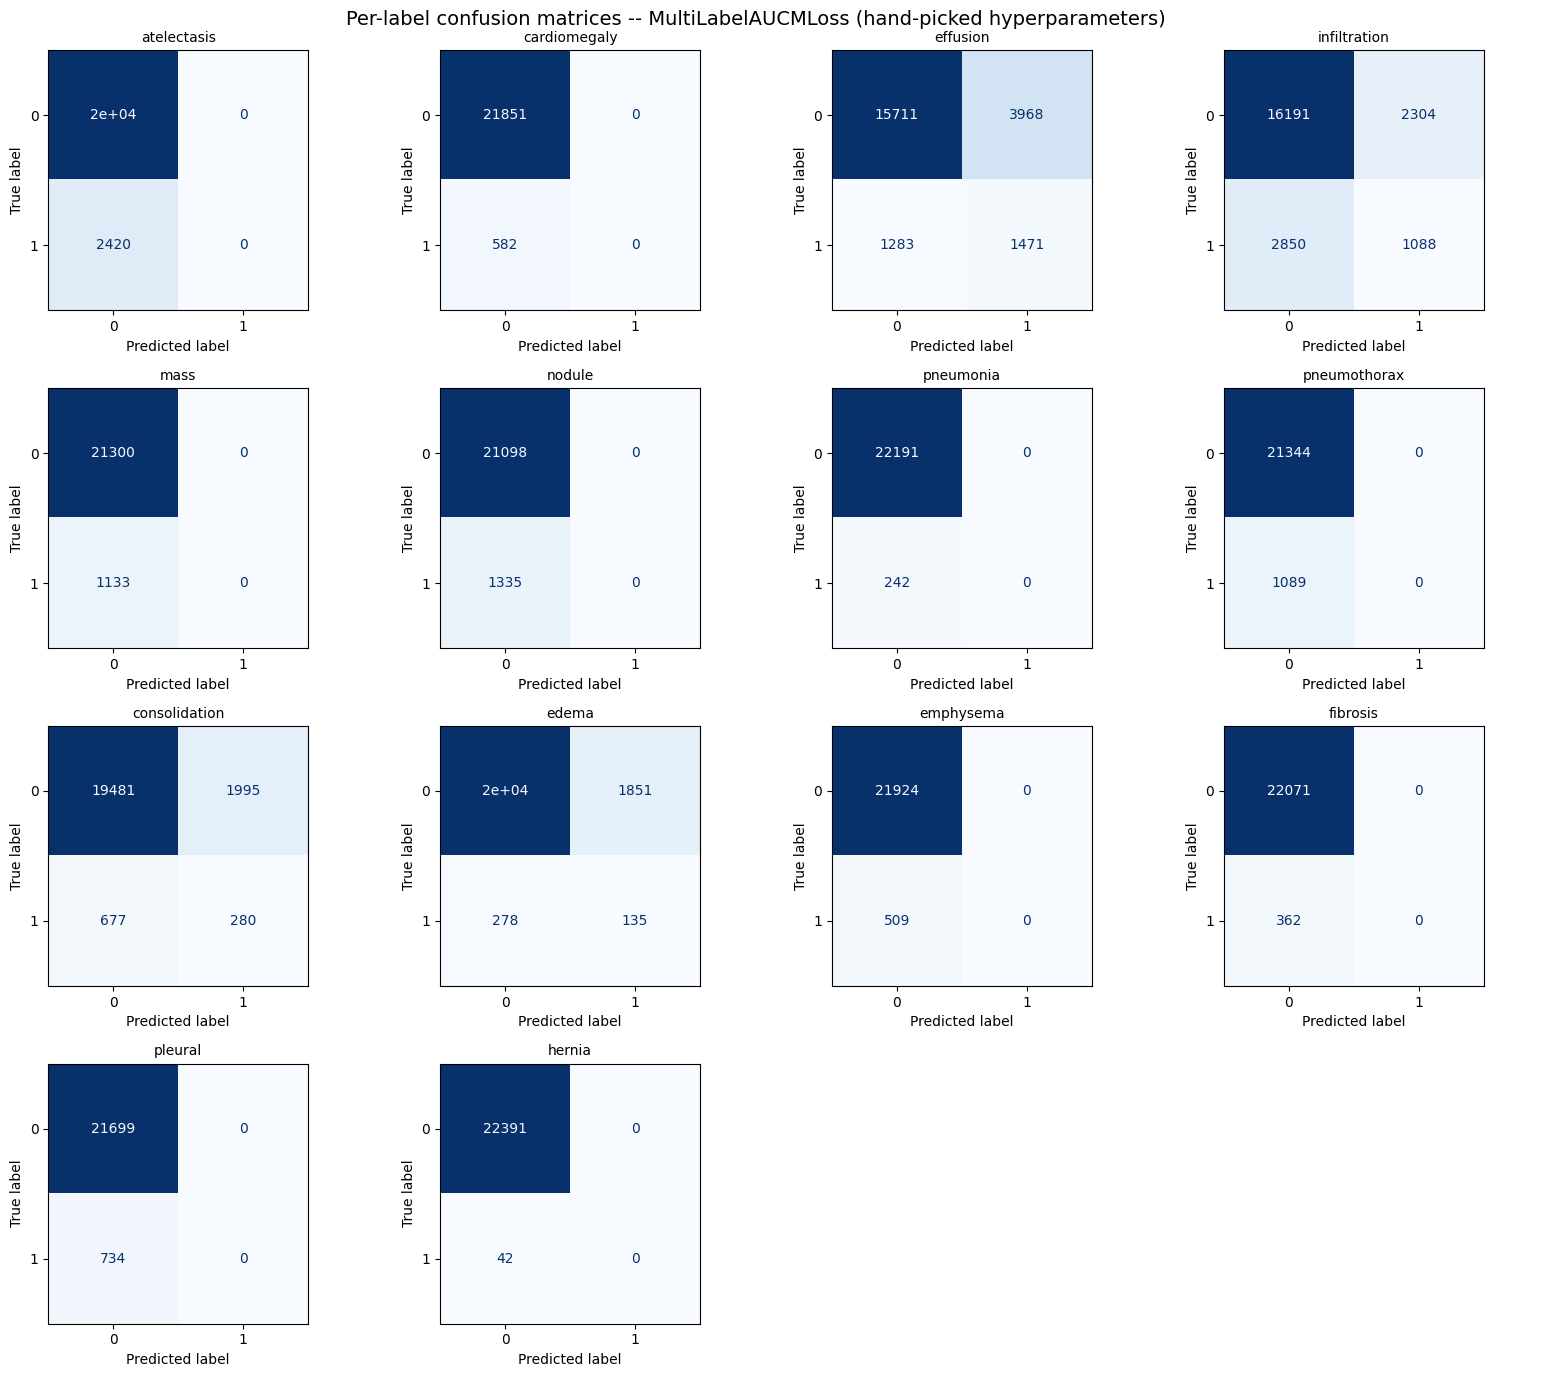

               precision    recall  f1-score   support

  atelectasis     0.0000    0.0000    0.0000      2420
 cardiomegaly     0.0000    0.0000    0.0000       582
     effusion     0.2705    0.5341    0.3591      2754
 infiltration     0.3208    0.2763    0.2969      3938
         mass     0.0000    0.0000    0.0000      1133
       nodule     0.0000    0.0000    0.0000      1335
    pneumonia     0.0000    0.0000    0.0000       242
 pneumothorax     0.0000    0.0000    0.0000      1089
consolidation     0.1231    0.2926    0.1733       957
        edema     0.0680    0.3269    0.1125       413
    emphysema     0.0000    0.0000    0.0000       509
     fibrosis     0.0000    0.0000    0.0000       362
      pleural     0.0000    0.0000    0.0000       734
       hernia     0.0000    0.0000    0.0000        42

    micro avg     0.2272    0.1801    0.2009     16510
    macro avg     0.0559    0.1021    0.0673     16510
 weighted avg     0.1305    0.1801    0.1436     16510
  sample

In [34]:
multilabel_metrics_report(aucm_test_label.numpy(), aucm_test_score.numpy(), disease_names,
                           "MultiLabelAUCMLoss (hand-picked hyperparameters)")

## Focal Loss

[Focal Loss](https://arxiv.org/abs/1708.02002) (Lin et al., 2017) down-weights easy examples. `torchvision.ops.sigmoid_focal_loss` works element-wise on raw logits, so it applies directly to the 14 outputs as independent binary decisions.

Same setup as pos_weight BCE (ResNet-20, `train_d` / `val_d`, Adam lr 1e-3, weight decay 1e-4), with alpha 0.25 and gamma 2.0. In torchvision's version alpha 0.25 weights positives 0.25 and negatives 0.75, which probably pushes scores for rare labels down.

In [35]:
from torchvision.ops import sigmoid_focal_loss

FOCAL_BATCH_SIZE = 512
focal_lr = 1e-3
focal_epochs = 50
focal_patience = 7
focal_alpha = 0.25
focal_gamma = 2.0

trainloader = data.DataLoader(dataset=train_d, batch_size=FOCAL_BATCH_SIZE, shuffle=True)
valloader = data.DataLoader(dataset=val_d, batch_size=FOCAL_BATCH_SIZE, shuffle=False, num_workers=2)
trainloader_eval = data.DataLoader(dataset=train_d, batch_size=FOCAL_BATCH_SIZE, shuffle=False, num_workers=2)

# ResNet-20: CIFAR-style stem, see Overview
focal_model = ResNet20(pretrained=False, last_activation=None, num_classes=14)
focal_model.conv1 = torch.nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False)

focal_optimizer = torch.optim.Adam(focal_model.parameters(), lr=focal_lr, weight_decay=0.0001)

# sigmoid_focal_loss on raw logits, mean over batch x label
def focal_loss_fn(y_pred, y_true):
    return sigmoid_focal_loss(y_pred, y_true, alpha=focal_alpha, gamma=focal_gamma, reduction='mean')

train_with_logits_loss(focal_model, focal_loss_fn, focal_optimizer, focal_epochs, trainloader,
                       trainloader_eval, valloader, patience=focal_patience, min_delta=MIN_DELTA)

Start Training
------------------------------
device: cuda
Epoch=0, BatchID=0, Val_AUC=0.4884
0
Epoch=1, BatchID=0, Val_AUC=0.6108
0
Epoch=2, BatchID=0, Val_AUC=0.6416
0
Epoch=3, BatchID=0, Val_AUC=0.6669
0
Epoch=4, BatchID=0, Val_AUC=0.6795
0
Epoch=5, BatchID=0, Val_AUC=0.6850
0
Epoch=6, BatchID=0, Val_AUC=0.6978
0
Epoch=7, BatchID=0, Val_AUC=0.7106
0
Epoch=8, BatchID=0, Val_AUC=0.7110
1
Epoch=9, BatchID=0, Val_AUC=0.6998
2
Epoch=10, BatchID=0, Val_AUC=0.7200
0
Epoch=11, BatchID=0, Val_AUC=0.7185
1
Epoch=12, BatchID=0, Val_AUC=0.7248
0
Epoch=13, BatchID=0, Val_AUC=0.7218
1
Epoch=14, BatchID=0, Val_AUC=0.6998
2
Epoch=15, BatchID=0, Val_AUC=0.7230
0
Epoch=16, BatchID=0, Val_AUC=0.7122
1
Epoch=17, BatchID=0, Val_AUC=0.7224
0
Epoch=18, BatchID=0, Val_AUC=0.6998
1
Epoch=19, BatchID=0, Val_AUC=0.7078
0
Epoch=20, BatchID=0, Val_AUC=0.7182
0
Epoch=21, BatchID=0, Val_AUC=0.7170
1
Epoch=22, BatchID=0, Val_AUC=0.7280
0
Epoch=23, BatchID=0, Val_AUC=0.6955
1
Epoch=24, BatchID=0, Val_AUC=0.7084
0
E

In [36]:
# focal: test ROC-AUC
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
focal_test_loader = data.DataLoader(dataset=test_dataset, batch_size=FOCAL_BATCH_SIZE)

score_list, label_list = [], []
# eval mode: BatchNorm uses running statistics
focal_model.eval()
with torch.no_grad():
    for _, d in enumerate(focal_test_loader, 0):
        tmp_data, tmp_label = d
        tmp_data = tmp_data.to(device)
        tmp_score = torch.sigmoid(focal_model(tmp_data)).detach().clone().cpu()
        score_list.append(tmp_score)
        label_list.append(tmp_label.cpu())

focal_test_label = torch.cat(label_list)
focal_test_score = torch.cat(score_list)

focal_test_auc_per_label = metrics.roc_auc_score(focal_test_label, focal_test_score, average=None)
focal_test_auc_mean = metrics.roc_auc_score(focal_test_label, focal_test_score, average='macro')
print("Per-label test AUC (Focal Loss):", focal_test_auc_per_label)
print("Mean test AUC (Focal Loss): %.4f" % focal_test_auc_mean)

Per-label test AUC (Focal Loss): [0.73964494 0.81899745 0.81217527 0.65174054 0.66731176 0.61297572
 0.68000746 0.75751729 0.76734524 0.84507552 0.6923     0.7077749
 0.65619135 0.75598083]
Mean test AUC (Focal Loss): 0.7261


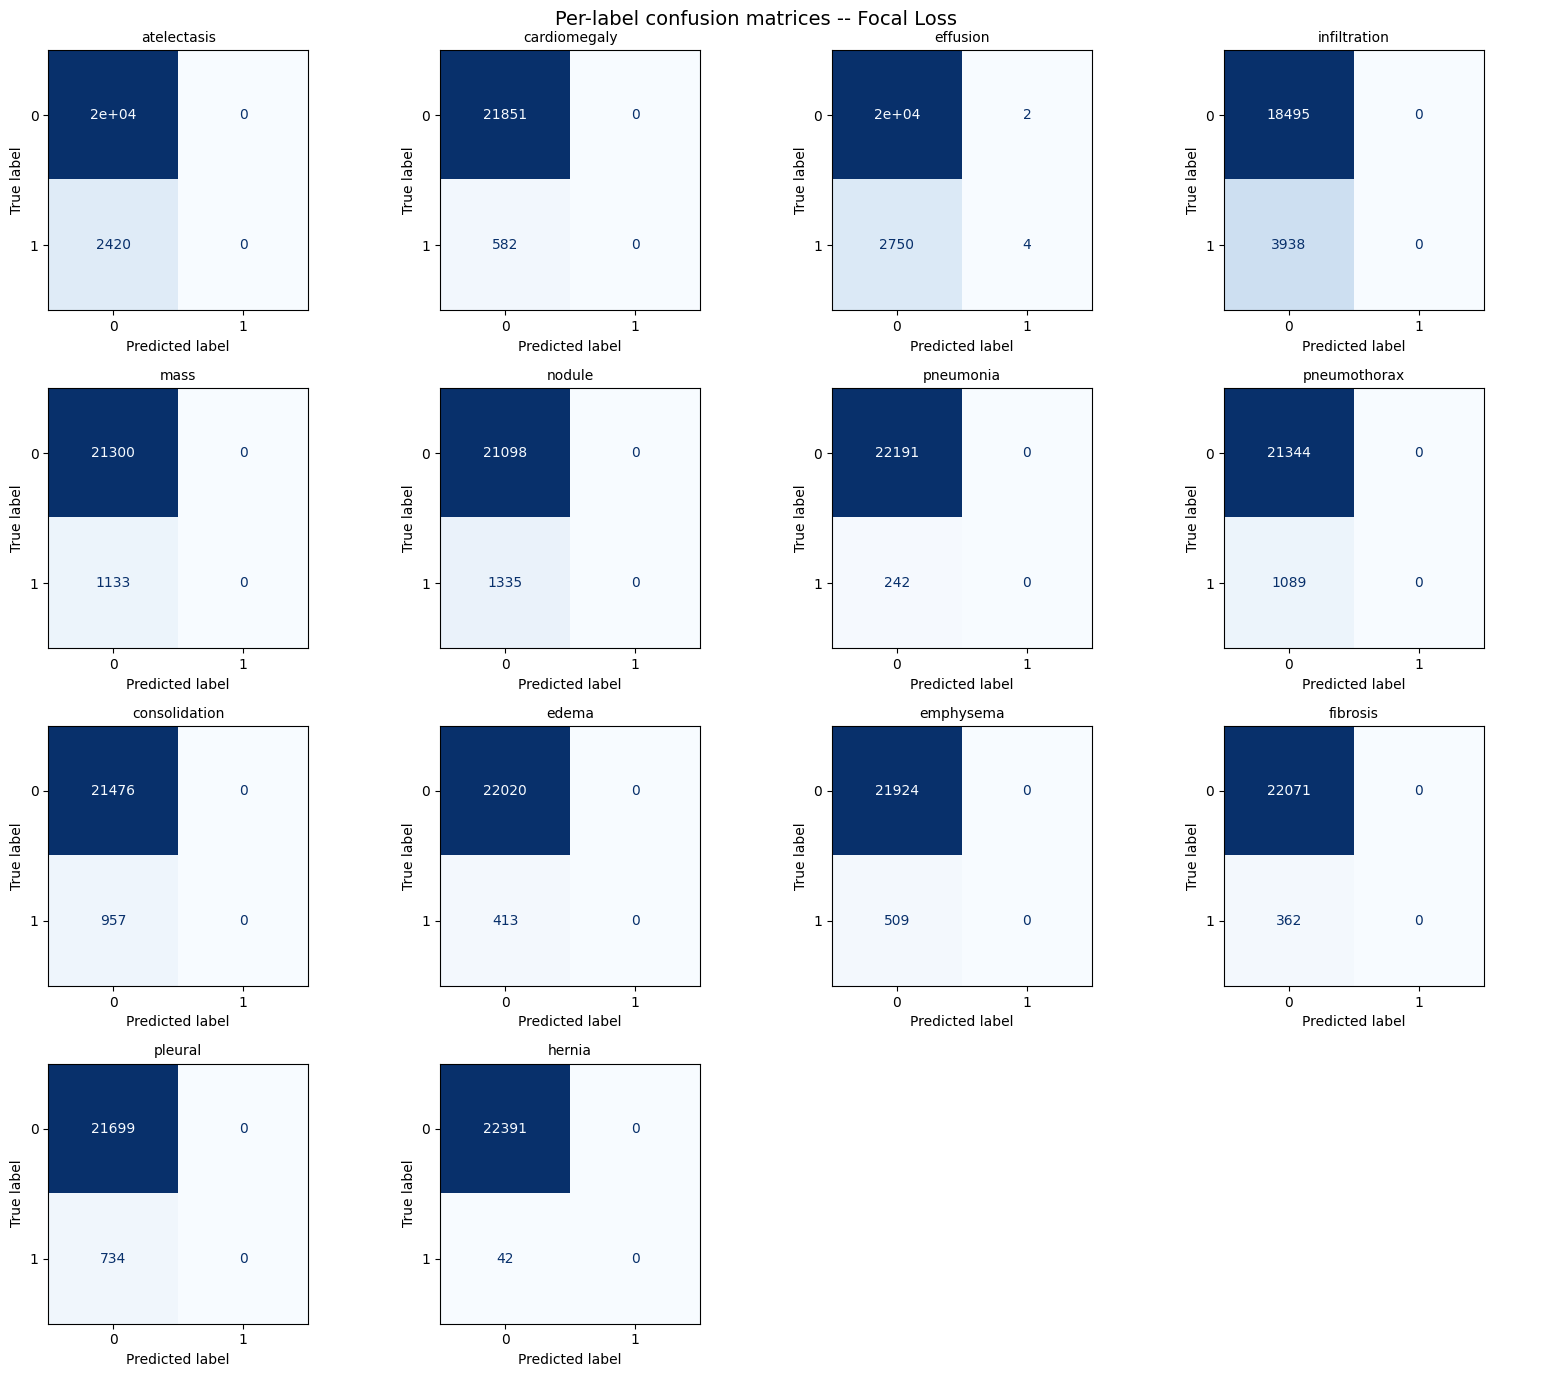

               precision    recall  f1-score   support

  atelectasis     0.0000    0.0000    0.0000      2420
 cardiomegaly     0.0000    0.0000    0.0000       582
     effusion     0.6667    0.0015    0.0029      2754
 infiltration     0.0000    0.0000    0.0000      3938
         mass     0.0000    0.0000    0.0000      1133
       nodule     0.0000    0.0000    0.0000      1335
    pneumonia     0.0000    0.0000    0.0000       242
 pneumothorax     0.0000    0.0000    0.0000      1089
consolidation     0.0000    0.0000    0.0000       957
        edema     0.0000    0.0000    0.0000       413
    emphysema     0.0000    0.0000    0.0000       509
     fibrosis     0.0000    0.0000    0.0000       362
      pleural     0.0000    0.0000    0.0000       734
       hernia     0.0000    0.0000    0.0000        42

    micro avg     0.6667    0.0002    0.0005     16510
    macro avg     0.0476    0.0001    0.0002     16510
 weighted avg     0.1112    0.0002    0.0005     16510
  sample

In [37]:
multilabel_metrics_report(focal_test_label.numpy(), focal_test_score.numpy(), disease_names, "Focal Loss")

## Threshold tuning

Balanced accuracy, MCC and F1 depend on the decision threshold, and 0.5 may not suit rare labels. Per arm and label, the threshold maximizes Youden's J (TPR - FPR) on validation scores, and the test set plays no part. ROC-AUC and PR-AUC don't change.

Youden's J is balanced accuracy up to scale, so MCC and F1 can move either way. Every tuned threshold is below 0.5, and Baseline's are the lowest for every label. Hernia has only 41 validation positives, so its thresholds are noisy. Grids at the tuned thresholds follow for all four arms.

In [38]:
def predict_scores(model, dataset_or_loader, batch_size=512):
    # sigmoid scores, shape (N, 14), as a numpy array. eval mode: BatchNorm uses running statistics
    device = next(model.parameters()).device
    loader = dataset_or_loader
    if not isinstance(loader, data.DataLoader):
        loader = data.DataLoader(dataset=loader, batch_size=batch_size, shuffle=False)
    model.eval()
    scores = []
    with torch.no_grad():
        for batch_data, _ in loader:
            scores.append(torch.sigmoid(model(batch_data.to(device))).cpu())
    return torch.cat(scores).numpy()

In [39]:
from sklearn.metrics import roc_curve

def tune_thresholds(y_val, s_val):
    # one threshold per label: maximize Youden's J = TPR - FPR on the validation scores (never test)
    # a label with no positives or no negatives in y_val falls back to 0.5
    n_labels = y_val.shape[1]
    thresholds = np.full(n_labels, 0.5)
    for i in range(n_labels):
        n_pos = int(y_val[:, i].sum())
        if n_pos == 0 or n_pos == y_val.shape[0]:
            continue
        fpr, tpr, roc_thresholds = roc_curve(y_val[:, i], s_val[:, i])
        # skip index 0: its threshold is a sentinel above every score
        best = 1 + np.argmax((tpr - fpr)[1:])
        thresholds[i] = roc_thresholds[best]
    return thresholds

In [40]:
from sklearn.metrics import f1_score

def macro_threshold_metrics(y_true, y_score, thresholds):
    # macro (over labels) balanced accuracy, MCC and F1 at per-label thresholds
    y_true = y_true.astype(int)
    y_pred = (y_score >= np.asarray(thresholds)[None, :]).astype(int)
    cols = range(y_true.shape[1])
    bal = np.mean([balanced_accuracy_score(y_true[:, i], y_pred[:, i]) for i in cols])
    mcc = np.mean([matthews_corrcoef(y_true[:, i], y_pred[:, i]) for i in cols])
    f1 = np.mean([f1_score(y_true[:, i], y_pred[:, i], zero_division=0) for i in cols])
    return bal, mcc, f1

# per arm: model, validation set, batch size, test labels, test scores
# Baseline validates on val_dataset1, the others on val_d (same images and labels)
threshold_arms = {
    'Baseline': (baseline_model, val_dataset1, BASELINE_BATCH_SIZE,
                 baseline_test_label.numpy(), baseline_test_score.numpy()),
    'pos_weight BCE': (pos_weight_model, val_d, POS_WEIGHT_BATCH_SIZE,
                       pos_weight_test_label.numpy(), pos_weight_test_score.numpy()),
    'Focal Loss': (focal_model, val_d, FOCAL_BATCH_SIZE,
                   focal_test_label.numpy(), focal_test_score.numpy()),
    'MultiLabelAUCMLoss': (aucm_model, val_d, AUCM_BATCH_SIZE,
                           aucm_test_label.numpy(), aucm_test_score.numpy()),
}

# val_dataset1 and val_d hold the same images and labels, so one label array serves every arm
y_val = val_dataset1.labels
assert (val_d.tensors[1].numpy() == y_val).all()

default_thresholds = np.full(y_val.shape[1], 0.5)
tuned_thresholds = {}
threshold_rows = {}
for arm_name, (arm_model, arm_val, arm_batch_size, y_test, s_test) in threshold_arms.items():
    # fresh validation loader per arm
    arm_val_loader = data.DataLoader(dataset=arm_val, batch_size=arm_batch_size, shuffle=False, num_workers=2)
    s_val = predict_scores(arm_model, arm_val_loader)
    tuned_thresholds[arm_name] = tune_thresholds(y_val, s_val)
    threshold_rows[arm_name] = (macro_threshold_metrics(y_test, s_test, default_thresholds),
                                macro_threshold_metrics(y_test, s_test, tuned_thresholds[arm_name]))

print(f"{'arm':20s} {'bal.acc @0.5':>13s} {'@tuned':>8s} {'MCC @0.5':>10s} {'@tuned':>8s} {'F1 @0.5':>9s} {'@tuned':>8s}")
for arm_name, (m_default, m_tuned) in threshold_rows.items():
    print(f"{arm_name:20s} {m_default[0]:13.4f} {m_tuned[0]:8.4f} {m_default[1]:10.4f} {m_tuned[1]:8.4f} "
          f"{m_default[2]:9.4f} {m_tuned[2]:8.4f}")

print()
print("Tuned thresholds (from validation):")
print(f"{'label':15s}" + "".join(f"{arm_name:>20s}" for arm_name in tuned_thresholds))
for i, label_name in enumerate(disease_names):
    print(f"{label_name:15s}" + "".join(f"{tuned_thresholds[arm_name][i]:20.3f}" for arm_name in tuned_thresholds))

arm                   bal.acc @0.5   @tuned   MCC @0.5   @tuned   F1 @0.5   @tuned
Baseline                    0.5072   0.6805     0.0345   0.1515    0.0258   0.1651
pos_weight BCE              0.5851   0.7003     0.1544   0.1703    0.1850   0.1784
Focal Loss                  0.5000   0.6666     0.0019   0.1393    0.0002   0.1564
MultiLabelAUCMLoss          0.5331   0.6034     0.0474   0.0908    0.0673   0.1307

Tuned thresholds (from validation):
label                      Baseline      pos_weight BCE          Focal Loss  MultiLabelAUCMLoss
atelectasis                   0.061               0.214               0.211               0.208
cardiomegaly                  0.013               0.088               0.171               0.154
effusion                      0.089               0.262               0.278               0.329
infiltration                  0.178               0.271               0.292               0.282
mass                          0.046               0.270             

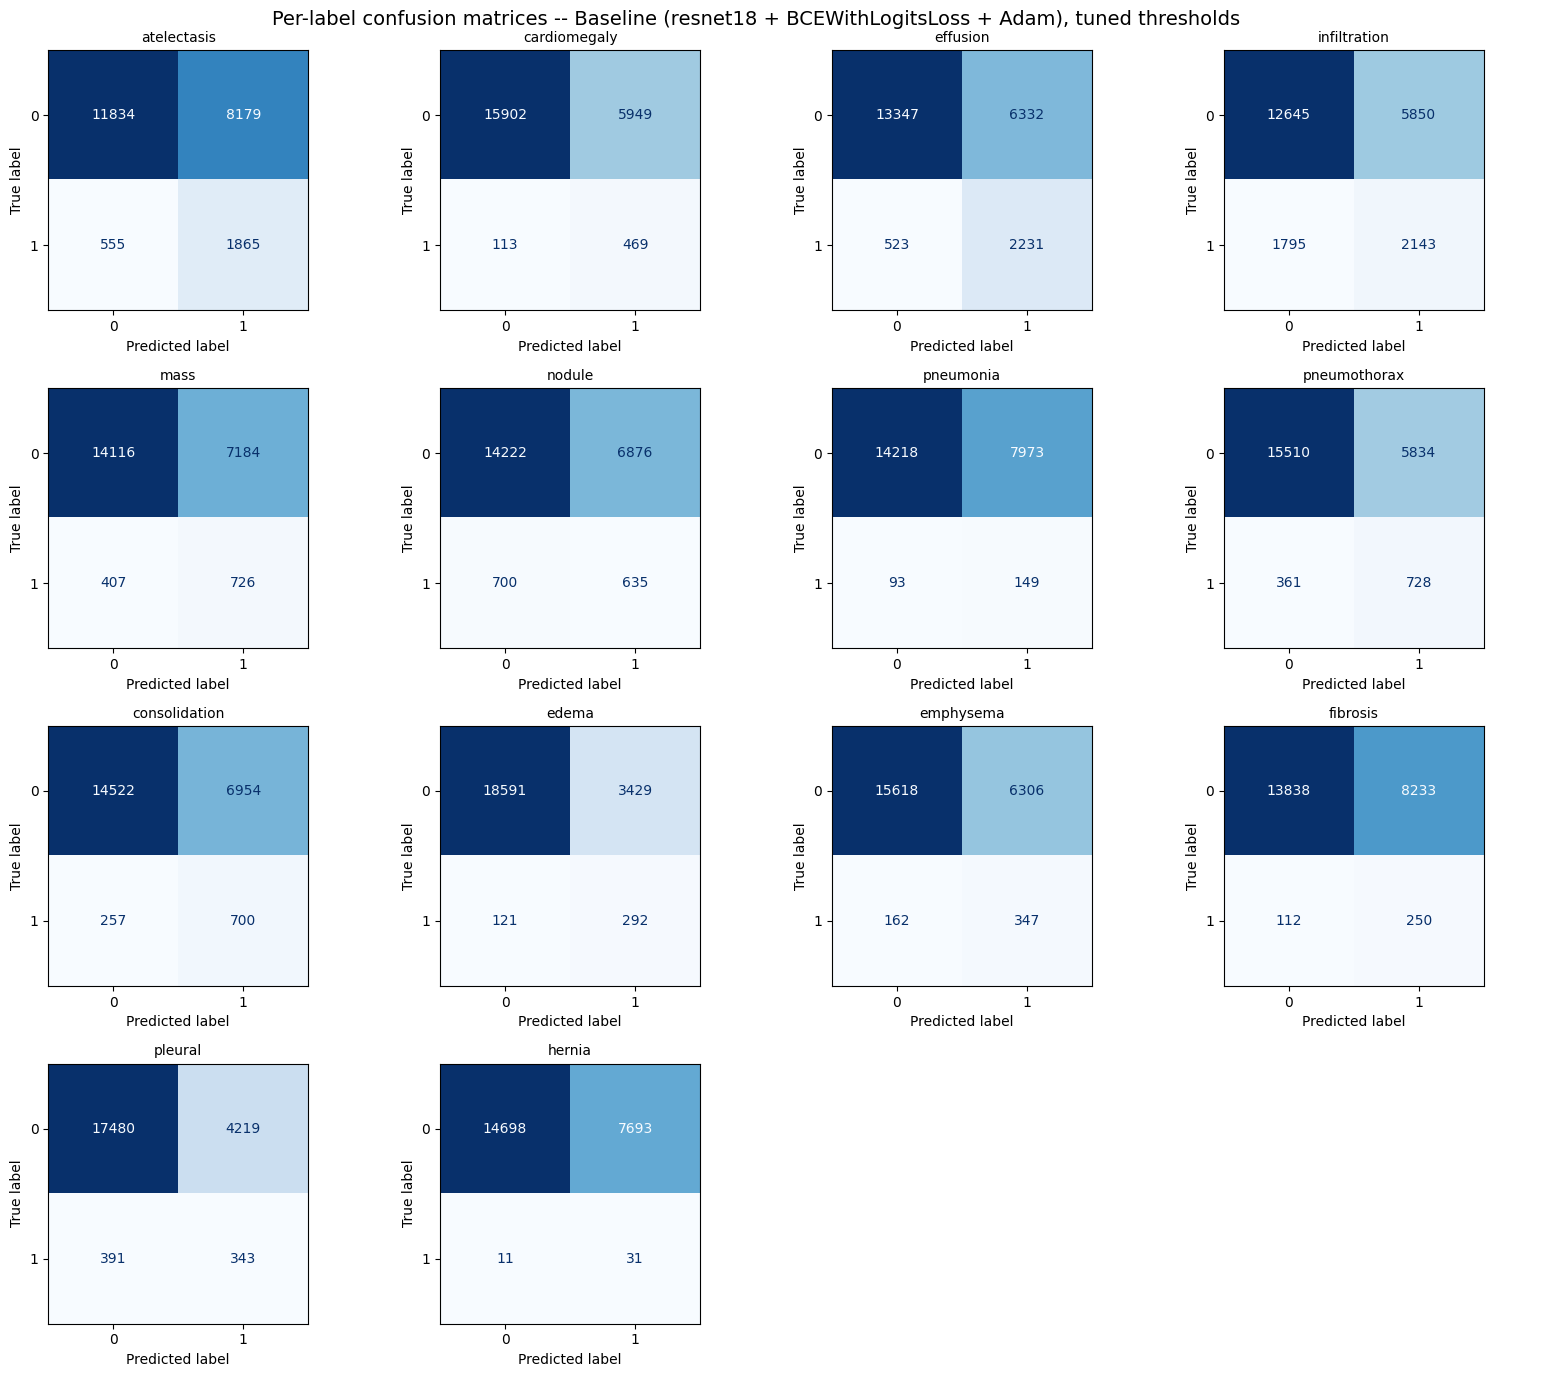

               precision    recall  f1-score   support

  atelectasis     0.1857    0.7707    0.2993      2420
 cardiomegaly     0.0731    0.8058    0.1340       582
     effusion     0.2605    0.8101    0.3943      2754
 infiltration     0.2681    0.5442    0.3592      3938
         mass     0.0918    0.6408    0.1606      1133
       nodule     0.0845    0.4757    0.1436      1335
    pneumonia     0.0183    0.6157    0.0356       242
 pneumothorax     0.1109    0.6685    0.1903      1089
consolidation     0.0915    0.7315    0.1626       957
        edema     0.0785    0.7070    0.1413       413
    emphysema     0.0522    0.6817    0.0969       509
     fibrosis     0.0295    0.6906    0.0565       362
      pleural     0.0752    0.4673    0.1295       734
       hernia     0.0040    0.7381    0.0080        42

    micro avg     0.1070    0.6608    0.1842     16510
    macro avg     0.1017    0.6677    0.1651     16510
 weighted avg     0.1708    0.6608    0.2587     16510
  sample

In [41]:
# confusion-matrix grid at the tuned thresholds, Baseline
multilabel_metrics_report(baseline_test_label.numpy(), baseline_test_score.numpy(), disease_names,
                           "Baseline (resnet18 + BCEWithLogitsLoss + Adam)",
                           thresholds=tuned_thresholds['Baseline'])

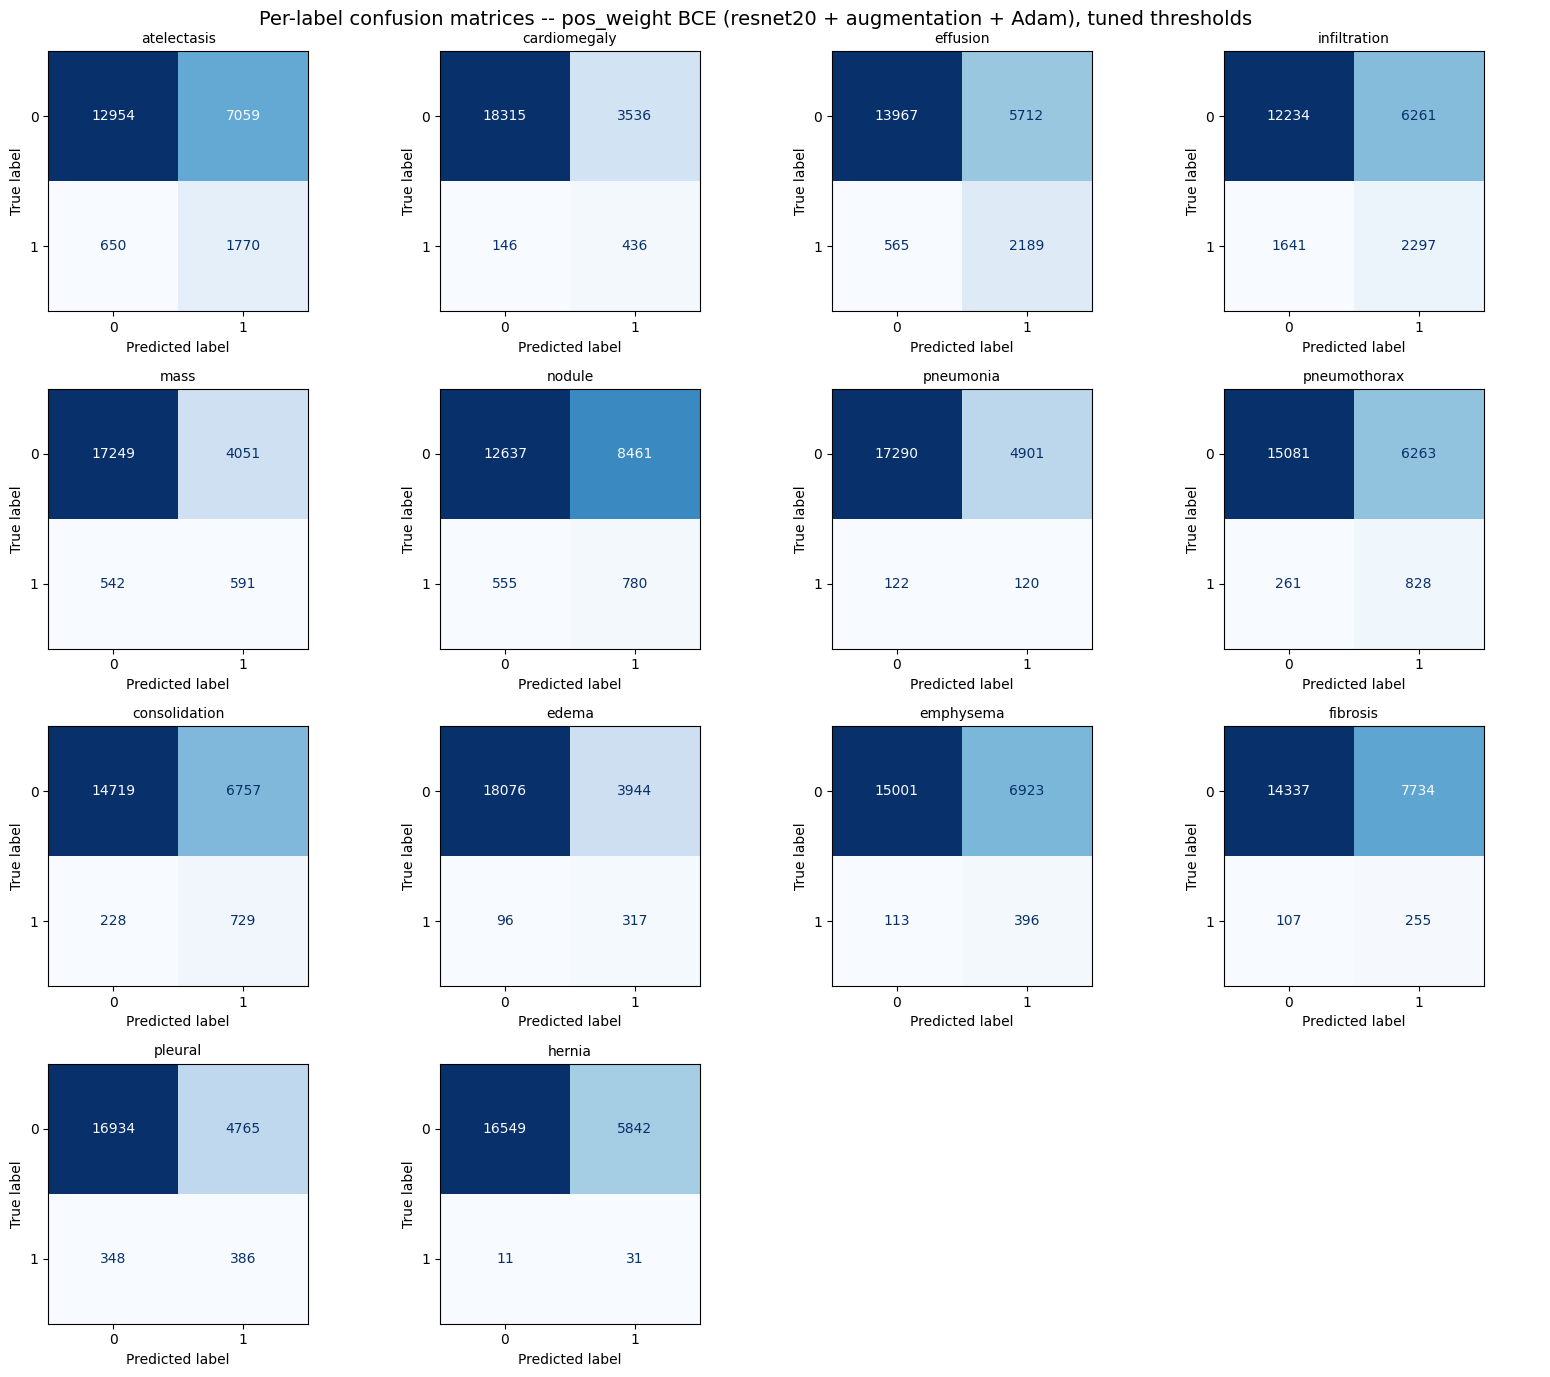

               precision    recall  f1-score   support

  atelectasis     0.2005    0.7314    0.3147      2420
 cardiomegaly     0.1098    0.7491    0.1915       582
     effusion     0.2771    0.7948    0.4109      2754
 infiltration     0.2684    0.5833    0.3676      3938
         mass     0.1273    0.5216    0.2047      1133
       nodule     0.0844    0.5843    0.1475      1335
    pneumonia     0.0239    0.4959    0.0456       242
 pneumothorax     0.1168    0.7603    0.2024      1089
consolidation     0.0974    0.7618    0.1727       957
        edema     0.0744    0.7676    0.1356       413
    emphysema     0.0541    0.7780    0.1012       509
     fibrosis     0.0319    0.7044    0.0611       362
      pleural     0.0749    0.5259    0.1312       734
       hernia     0.0053    0.7381    0.0105        42

    micro avg     0.1192    0.6738    0.2026     16510
    macro avg     0.1104    0.6783    0.1784     16510
 weighted avg     0.1803    0.6738    0.2728     16510
  sample

In [42]:
# confusion-matrix grid at the tuned thresholds, pos_weight BCE
multilabel_metrics_report(pos_weight_test_label.numpy(), pos_weight_test_score.numpy(), disease_names,
                           "pos_weight BCE (resnet20 + augmentation + Adam)",
                           thresholds=tuned_thresholds['pos_weight BCE'])

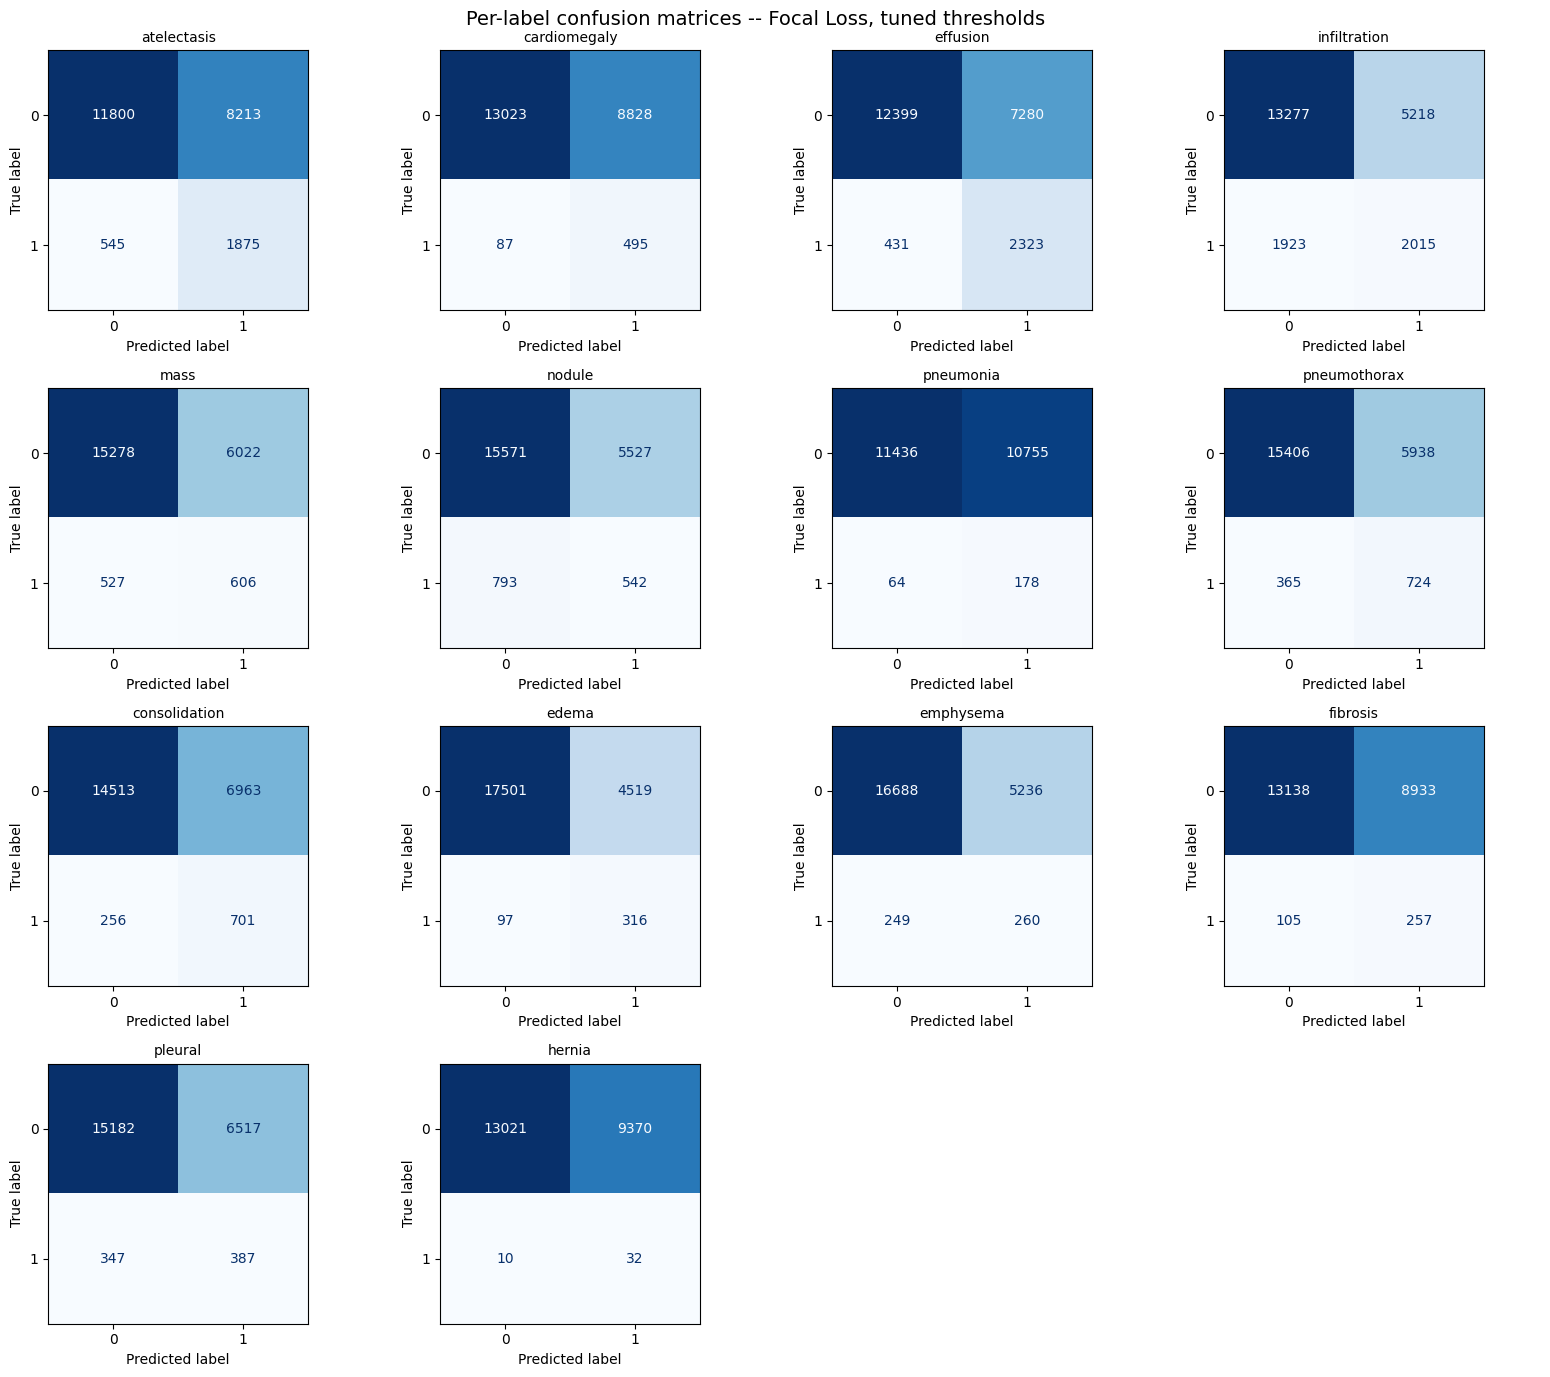

               precision    recall  f1-score   support

  atelectasis     0.1859    0.7748    0.2998      2420
 cardiomegaly     0.0531    0.8505    0.0999       582
     effusion     0.2419    0.8435    0.3760      2754
 infiltration     0.2786    0.5117    0.3608      3938
         mass     0.0914    0.5349    0.1562      1133
       nodule     0.0893    0.4060    0.1464      1335
    pneumonia     0.0163    0.7355    0.0319       242
 pneumothorax     0.1087    0.6648    0.1868      1089
consolidation     0.0915    0.7325    0.1626       957
        edema     0.0654    0.7651    0.1204       413
    emphysema     0.0473    0.5108    0.0866       509
     fibrosis     0.0280    0.7099    0.0538       362
      pleural     0.0561    0.5272    0.1013       734
       hernia     0.0034    0.7619    0.0068        42

    micro avg     0.0973    0.6488    0.1693     16510
    macro avg     0.0969    0.6664    0.1564     16510
 weighted avg     0.1683    0.6488    0.2524     16510
  sample

In [43]:
# confusion-matrix grid at the tuned thresholds, Focal Loss
multilabel_metrics_report(focal_test_label.numpy(), focal_test_score.numpy(), disease_names,
                           "Focal Loss",
                           thresholds=tuned_thresholds['Focal Loss'])

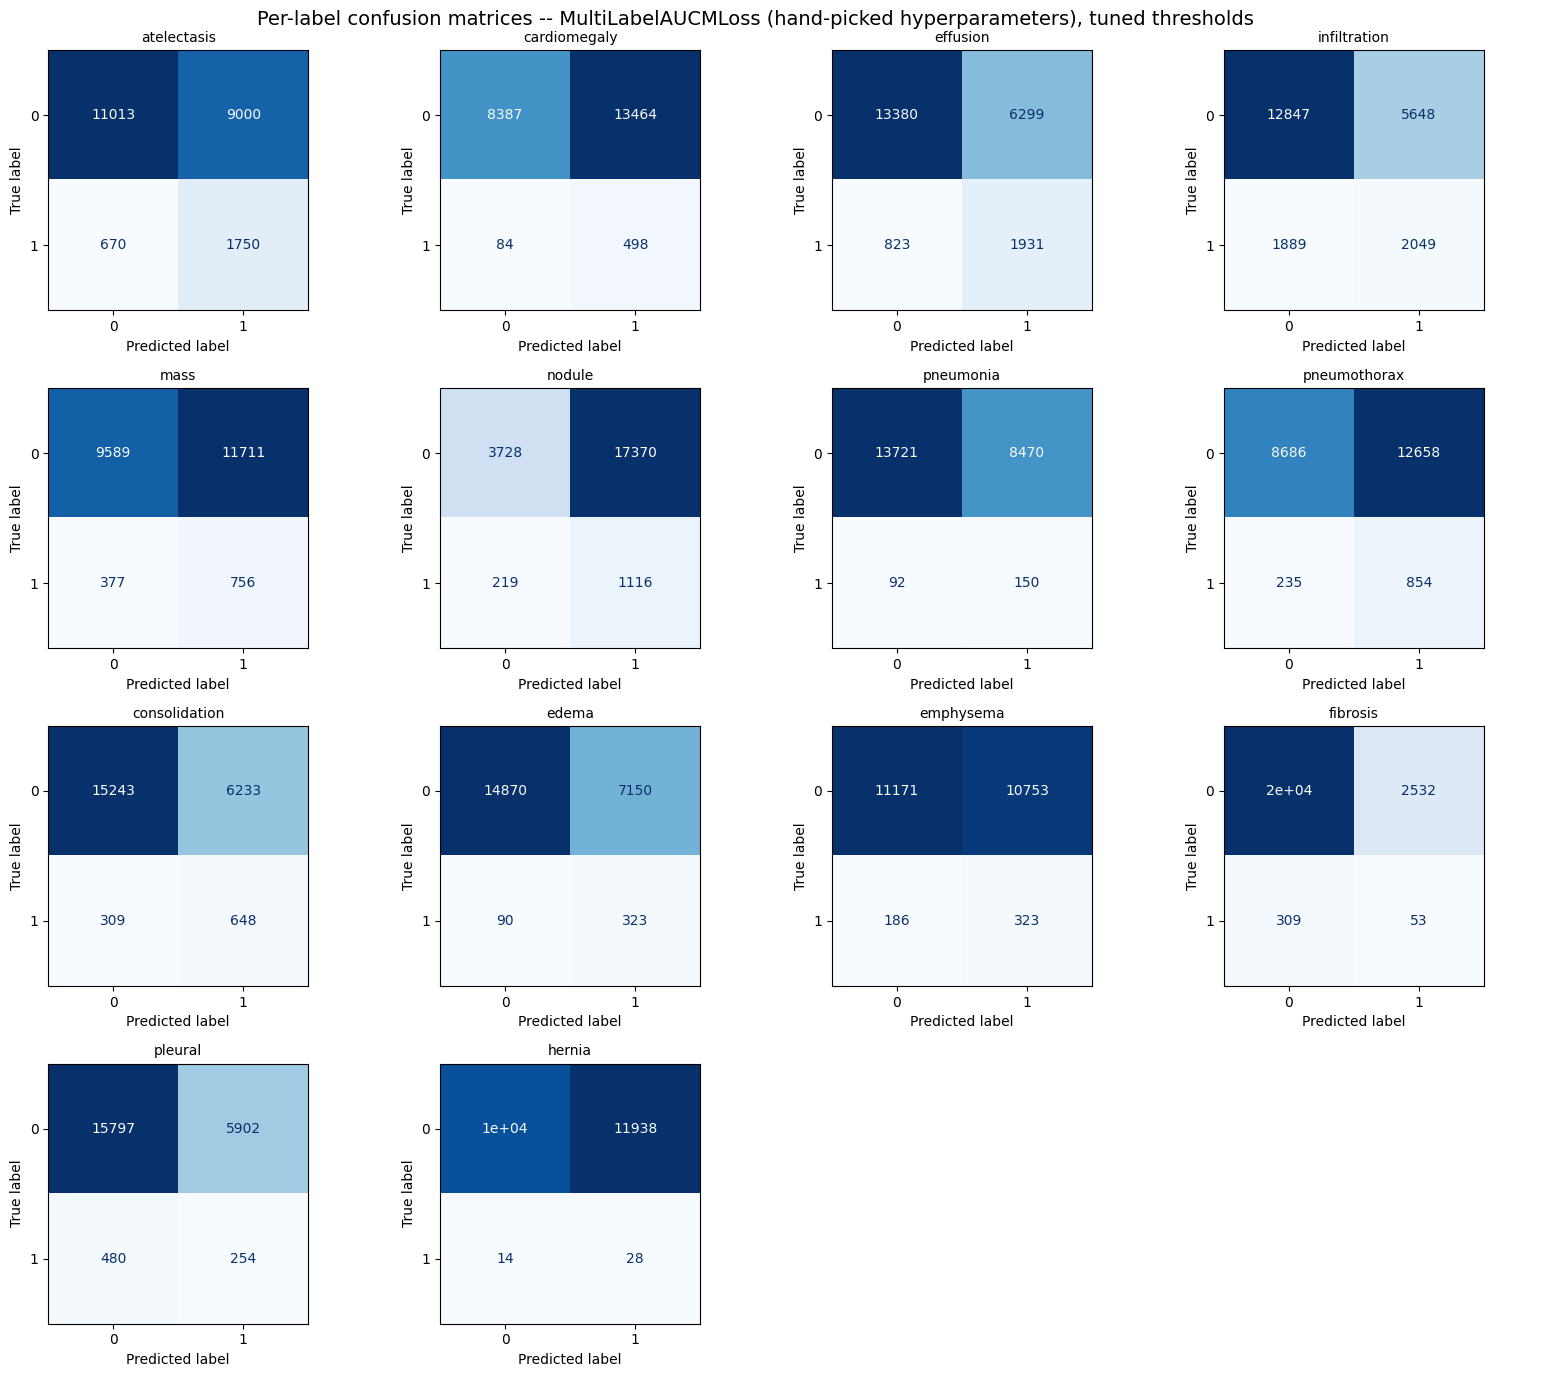

               precision    recall  f1-score   support

  atelectasis     0.1628    0.7231    0.2658      2420
 cardiomegaly     0.0357    0.8557    0.0685       582
     effusion     0.2346    0.7012    0.3516      2754
 infiltration     0.2662    0.5203    0.3522      3938
         mass     0.0606    0.6673    0.1112      1133
       nodule     0.0604    0.8360    0.1126      1335
    pneumonia     0.0174    0.6198    0.0339       242
 pneumothorax     0.0632    0.7842    0.1170      1089
consolidation     0.0942    0.6771    0.1653       957
        edema     0.0432    0.7821    0.0819       413
    emphysema     0.0292    0.6346    0.0558       509
     fibrosis     0.0205    0.1464    0.0360       362
      pleural     0.0413    0.3460    0.0737       734
       hernia     0.0023    0.6667    0.0047        42

    micro avg     0.0767    0.6501    0.1373     16510
    macro avg     0.0808    0.6400    0.1307     16510
 weighted avg     0.1509    0.6501    0.2264     16510
  sample

In [44]:
# confusion-matrix grid at the tuned thresholds, MultiLabelAUCMLoss
multilabel_metrics_report(aucm_test_label.numpy(), aucm_test_score.numpy(), disease_names,
                           "MultiLabelAUCMLoss (hand-picked hyperparameters)",
                           thresholds=tuned_thresholds['MultiLabelAUCMLoss'])

## Bootstrap

Resample the test set with replacement 1000 times, using the same resample for all four arms, and compute each arm's macro ROC-AUC. The intervals are 95% percentile intervals per arm and per pairwise difference. Only ROC-AUC gets an interval. It covers test-set sampling only.

In [45]:
def bootstrap_compare(results, n_boot=1000, seed=123):
    # results: name -> (y_true, y_score), all on the same test set. returns name -> bootstrap macro-AUCs
    rng = np.random.default_rng(seed)
    n = next(iter(results.values()))[0].shape[0]
    boot_aucs = {name: [] for name in results}
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)  # same resample for every method this iteration
        for name, (yt, ys) in results.items():
            try:
                boot_aucs[name].append(metrics.roc_auc_score(yt[idx], ys[idx], average='macro'))
            except ValueError:
                # a resample can miss all positives of a rare label
                boot_aucs[name].append(np.nan)
    return {name: np.array(v) for name, v in boot_aucs.items()}

results = {
    'Baseline (BCE)': (baseline_test_label.numpy(), baseline_test_score.numpy()),
    'pos_weight BCE': (pos_weight_test_label.numpy(), pos_weight_test_score.numpy()),
    'Focal Loss': (focal_test_label.numpy(), focal_test_score.numpy()),
    'MultiLabelAUCMLoss': (aucm_test_label.numpy(), aucm_test_score.numpy()),
}

boot = bootstrap_compare(results)

print(f"{'method':20s} {'mean':>8s} {'2.5%':>8s} {'97.5%':>8s}")
for name, aucs in boot.items():
    clean = aucs[~np.isnan(aucs)]
    lo, hi = np.percentile(clean, [2.5, 97.5])
    print(f"{name:20s} {clean.mean():8.4f} {lo:8.4f} {hi:8.4f}")

print()
print("Paired bootstrap difference (95% CI on the diff; CI excluding 0 => likely real difference):")
names = list(boot.keys())
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        diff = boot[names[i]] - boot[names[j]]
        diff = diff[~np.isnan(diff)]
        lo, hi = np.percentile(diff, [2.5, 97.5])
        flag = "  <-- likely real difference" if (lo > 0 or hi < 0) else ""
        print(f"  {names[i]} - {names[j]}: mean={diff.mean():+.4f}  95% CI=[{lo:+.4f}, {hi:+.4f}]{flag}")

method                   mean     2.5%    97.5%
Baseline (BCE)         0.7423   0.7352   0.7488
pos_weight BCE         0.7694   0.7632   0.7752
Focal Loss             0.7263   0.7188   0.7332
MultiLabelAUCMLoss     0.6329   0.6249   0.6402

Paired bootstrap difference (95% CI on the diff; CI excluding 0 => likely real difference):
  Baseline (BCE) - pos_weight BCE: mean=-0.0272  95% CI=[-0.0341, -0.0203]  <-- likely real difference
  Baseline (BCE) - Focal Loss: mean=+0.0160  95% CI=[+0.0094, +0.0230]  <-- likely real difference
  Baseline (BCE) - MultiLabelAUCMLoss: mean=+0.1094  95% CI=[+0.1013, +0.1178]  <-- likely real difference
  pos_weight BCE - Focal Loss: mean=+0.0432  95% CI=[+0.0353, +0.0512]  <-- likely real difference
  pos_weight BCE - MultiLabelAUCMLoss: mean=+0.1365  95% CI=[+0.1275, +0.1456]  <-- likely real difference
  Focal Loss - MultiLabelAUCMLoss: mean=+0.0934  95% CI=[+0.0865, +0.1003]  <-- likely real difference


## Results

| Arm | Val ROC-AUC (epoch) | Test macro ROC-AUC [95% CI] | PR-AUC (macro) | Bal. acc. @0.5 | Bal. acc. tuned | MCC @0.5 | MCC tuned | Macro F1 @0.5 | Macro F1 tuned |
|---|---|---|---|---|---|---|---|---|---|
| Baseline | 0.7501 (20) | 0.7424 [0.7352, 0.7488] | 0.1406 | 0.5072 | 0.6805 | 0.0345 | 0.1515 | 0.0258 | 0.1651 |
| pos_weight BCE | 0.7726 (49) | 0.7694 [0.7632, 0.7752] | 0.1573 | 0.5851 | 0.7003 | 0.1544 | 0.1703 | 0.1850 | 0.1784 |
| Focal Loss | 0.7301 (43) | 0.7261 [0.7188, 0.7332] | 0.1296 | 0.5000 | 0.6666 | 0.0019 | 0.1393 | 0.0002 | 0.1564 |
| Hand-picked (MultiLabelAUCMLoss) | 0.6394 (33) | 0.6328 [0.6249, 0.6402] | 0.0873 | 0.5331 | 0.6034 | 0.0474 | 0.0908 | 0.0673 | 0.1307 |

Balanced accuracy, MCC and F1 are macro averages over the 14 labels, at 0.5 and at per-label thresholds tuned on validation.

- pos_weight BCE is highest on every column. All six pairwise ROC-AUC differences have bootstrap CIs that exclude 0 (Baseline minus pos_weight BCE is -0.027, CI [-0.034, -0.020]).
- pos_weight BCE differs from Baseline in loss, backbone and augmentation. Focal Loss shares its backbone, augmentation and optimizer but scores 0.043 lower, so the loss probably matters most.
- At 0.5 Baseline and Focal Loss predict almost no positives, so ROC-AUC and PR-AUC are the better comparison there. Tuned thresholds rank the arms as ROC-AUC does on all three metrics, and F1 falls only for pos_weight BCE (0.185 to 0.178).
- Hand-picked is last on ROC-AUC and PR-AUC but second on the 0.5 metrics. Its hyperparameters are untuned and its optimizer differs, so it says little about AUC-margin loss itself.

The val AUC of Baseline and Focal Loss swings between epochs. Hernia has only 42 test positives, so the largest per-label gain of pos_weight BCE over Baseline (hernia AUC 0.832 vs 0.742) may be noise. pos_weight BCE peaked at epoch 49 of 50 and may not have converged.